## Projet Analyse de données


### 1. Introduction et Problématique

La plateforme Steam regroupe aujourd'hui plus de 120 000 jeux, allant des petits projets indépendants aux blockbusters mondiaux. Pour comprendre comment cet immense catalogue est structuré, ce projet propose d'analyser les données de chaque titre (prix, genre, nombre de joueurs, succès) en utilisant des outils de statistiques avancées. 

L'idée est de ne plus voir ces jeux comme une simple liste, mais de comprendre les mécaniques cachées qui font qu'un jeu devient populaire ou reste invisible. Dès lors, ce projet a pour but d'étudier le jeu de données Steam en fonction des caractéristiques intrinsèques des jeux afin de répondre à la problématique suivante : 

**Est-ce que les caractéristiques de base d'un jeu (comme son prix, son genre ou son contenu) permettent de prédire mathématiquement s'il deviendra un succès ou s'il restera perdu dans la masse des jeux sans audience ?**

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('games.csv')
print(df.head())


     AppID                                   Name  Release date  \
0  2539430             Black Dragon Mage Playtest   Aug 1, 2023   
1   496350  Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016   
2  1034400      Mystery Solitaire The Black Raven   May 6, 2019   
3  3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024   
4  3631080                          Maze Quest VR  Apr 24, 2025   

  Estimated owners  Peak CCU  Required age  Price  Discount  DLC count  \
0            0 - 0         0             0   0.00         0          0   
1        0 - 20000         0             0   5.24        65          0   
2        0 - 20000         0             0   4.99         0          0   
3        0 - 20000         1             0   8.99         0          1   
4        0 - 20000         0             0   4.99         0          0   

                                      About the game  ...  \
0                                                NaN  ...   
1  Springtime, April: when the

In [150]:
df.dtypes

AppID                           int64
Name                              str
Release date                      str
Estimated owners                  str
Peak CCU                        int64
Required age                    int64
Price                         float64
Discount                        int64
DLC count                       int64
About the game                    str
Supported languages               str
Full audio languages              str
Reviews                           str
Header image                      str
Website                           str
Support url                       str
Support email                     str
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                    str
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements

In [151]:
df.describe()

,AppID,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,1.985386e+06,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,1.087595e+06,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,1.063175e+06,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,1.907380e+06,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,2.869560e+06,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,4.264350e+06,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


## Analyse exploratoire et unidimensionnelle


In [152]:

cols_a_retirer = [
    'AppID', 'Name', 'About the game', 'Notes', 'Reviews', 
    'Header image', 'Website', 'Support url', 'Support email', 
    'Metacritic url', 'Screenshots', 'Score rank', 'Movies', 'Tags', 'Reviews', 'Notes'
]


df = df.drop(columns=cols_a_retirer, errors='ignore')


print("Variables restantes dans le jeu de données :")
print(df.columns.tolist())
print(f"\nNombre de colonnes finales : {df.shape[1]}")

Variables restantes dans le jeu de données :
['Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'Discount', 'DLC count', 'Supported languages', 'Full audio languages', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'User score', 'Positive', 'Negative', 'Achievements', 'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres']

Nombre de colonnes finales : 26


On supprime ces variables car elles n'apportent rien à l'analyse des données et car certaines colonnes sont vides où beaucoup de données sont manquantes.

In [153]:
print("--- APERÇU DES DONNÉES (HEAD) ---")
display(df.head())

print("\n--- INFORMATIONS GÉNÉRALES (INFO) ---")
df.info()

print("\n--- RÉSUMÉ STATISTIQUE (DESCRIBE) ---")
display(df.describe())

print("\n--- DIMENSIONS DU DATASET ---")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

--- APERÇU DES DONNÉES (HEAD) ---


,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,Windows,...,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres
0,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],True,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
1,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],True,...,0,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure
2,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],True,...,0,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual
3,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],True,...,19,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation"
4,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],True,...,0,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access"



--- INFORMATIONS GÉNÉRALES (INFO) ---
<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Release date                122611 non-null  str    
 1   Estimated owners            122611 non-null  str    
 2   Peak CCU                    122611 non-null  int64  
 3   Required age                122611 non-null  int64  
 4   Price                       122611 non-null  float64
 5   Discount                    122611 non-null  int64  
 6   DLC count                   122611 non-null  int64  
 7   Supported languages         122611 non-null  str    
 8   Full audio languages        122611 non-null  str    
 9   Windows                     122611 non-null  bool   
 10  Mac                         122611 non-null  bool   
 11  Linux                       122611 non-null  bool   
 12  Metacritic score            122611 non-null 

,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks
count,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000
mean,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170
std,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
50%,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
75%,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
max,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000



--- DIMENSIONS DU DATASET ---
Nombre de lignes : 122611
Nombre de colonnes : 26


In [154]:
for col in ['Windows', 'Mac', 'Linux']:
    if col in df.columns:
        df[col] = (df[col].astype(str).str.lower() == 'true').astype(int)


print(df[['Windows', 'Mac', 'Linux']].head())
print("\nTypes finaux :")
print(df[['Windows', 'Mac', 'Linux']].dtypes)

   Windows  Mac  Linux
0        1    0      0
1        1    0      0
2        1    1      0
3        1    0      0
4        1    0      0

Types finaux :
Windows    int64
Mac        int64
Linux      int64
dtype: object


On convertit Windows, Mac et Linux en variables binaires ce qui facilite l'analyse des composantes.

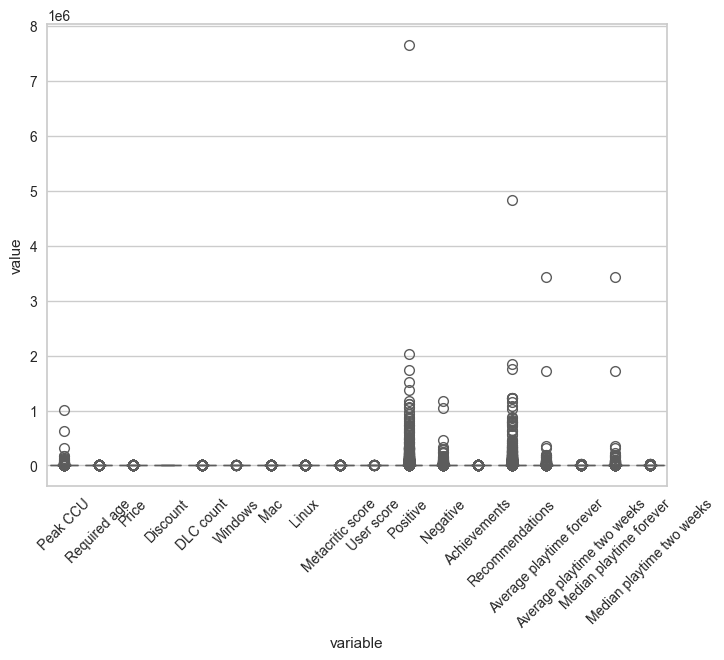

In [155]:
plt.rcParams['figure.figsize'] = (8, 6)
cols_num = df.select_dtypes(include=['int64', 'float64']).columns
df_melt = df[cols_num].melt()

sns.boxplot(data=df_melt, x='variable', y='value', hue='variable', 
            palette='hls', fill=True, legend=False)
plt.xticks(rotation=45)
plt.show()

L'analyse exploratoire initiale montre une hétérogénéité extrême des données. La présence d'outliers atteignant plusieurs millions d'unités (avis positifs) rend les variables de prix et de scores illisibles sur une échelle linéaire. Cela justifie le recours ultérieur à une transformation logarithmique et à une segmentation du dataset.

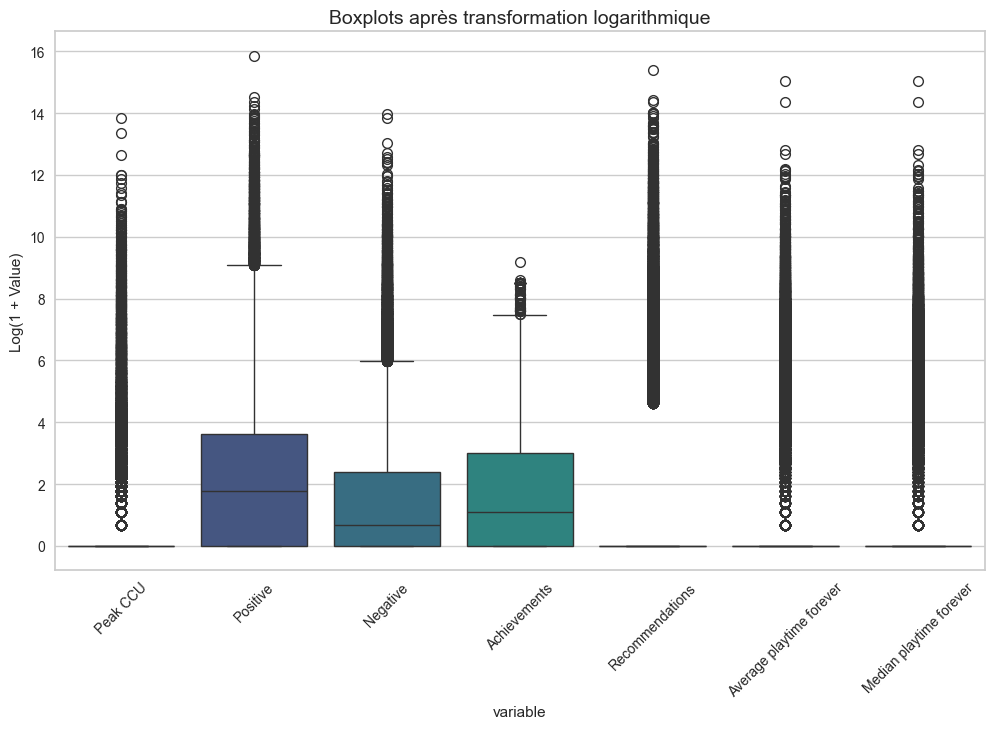

In [156]:
cols_to_log = ['Peak CCU', 'Positive', 'Negative', 'Achievements', 'Recommendations', 
               'Average playtime forever', 'Median playtime forever']

df_log = df.copy()
for col in cols_to_log:
    if col in df_log.columns:
        df_log[col] = np.log1p(df_log[col])

df_melted_log = df_log[cols_to_log].melt()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_melted_log, x='variable', y='value', hue='variable', 
            palette='viridis', fill=True, legend=False)

plt.xticks(rotation=45)
plt.ylabel("Log(1 + Value)")
plt.title("Boxplots après transformation logarithmique", fontsize=14)
plt.show()

La transformation $\log(1+x)$ sur les boxplots a permis de stabiliser la variance en convertissant les écarts de volume bruts en ordres de grandeur, rendant ainsi les distributions enfin lisibles.

## Analyse multidimensionnelle

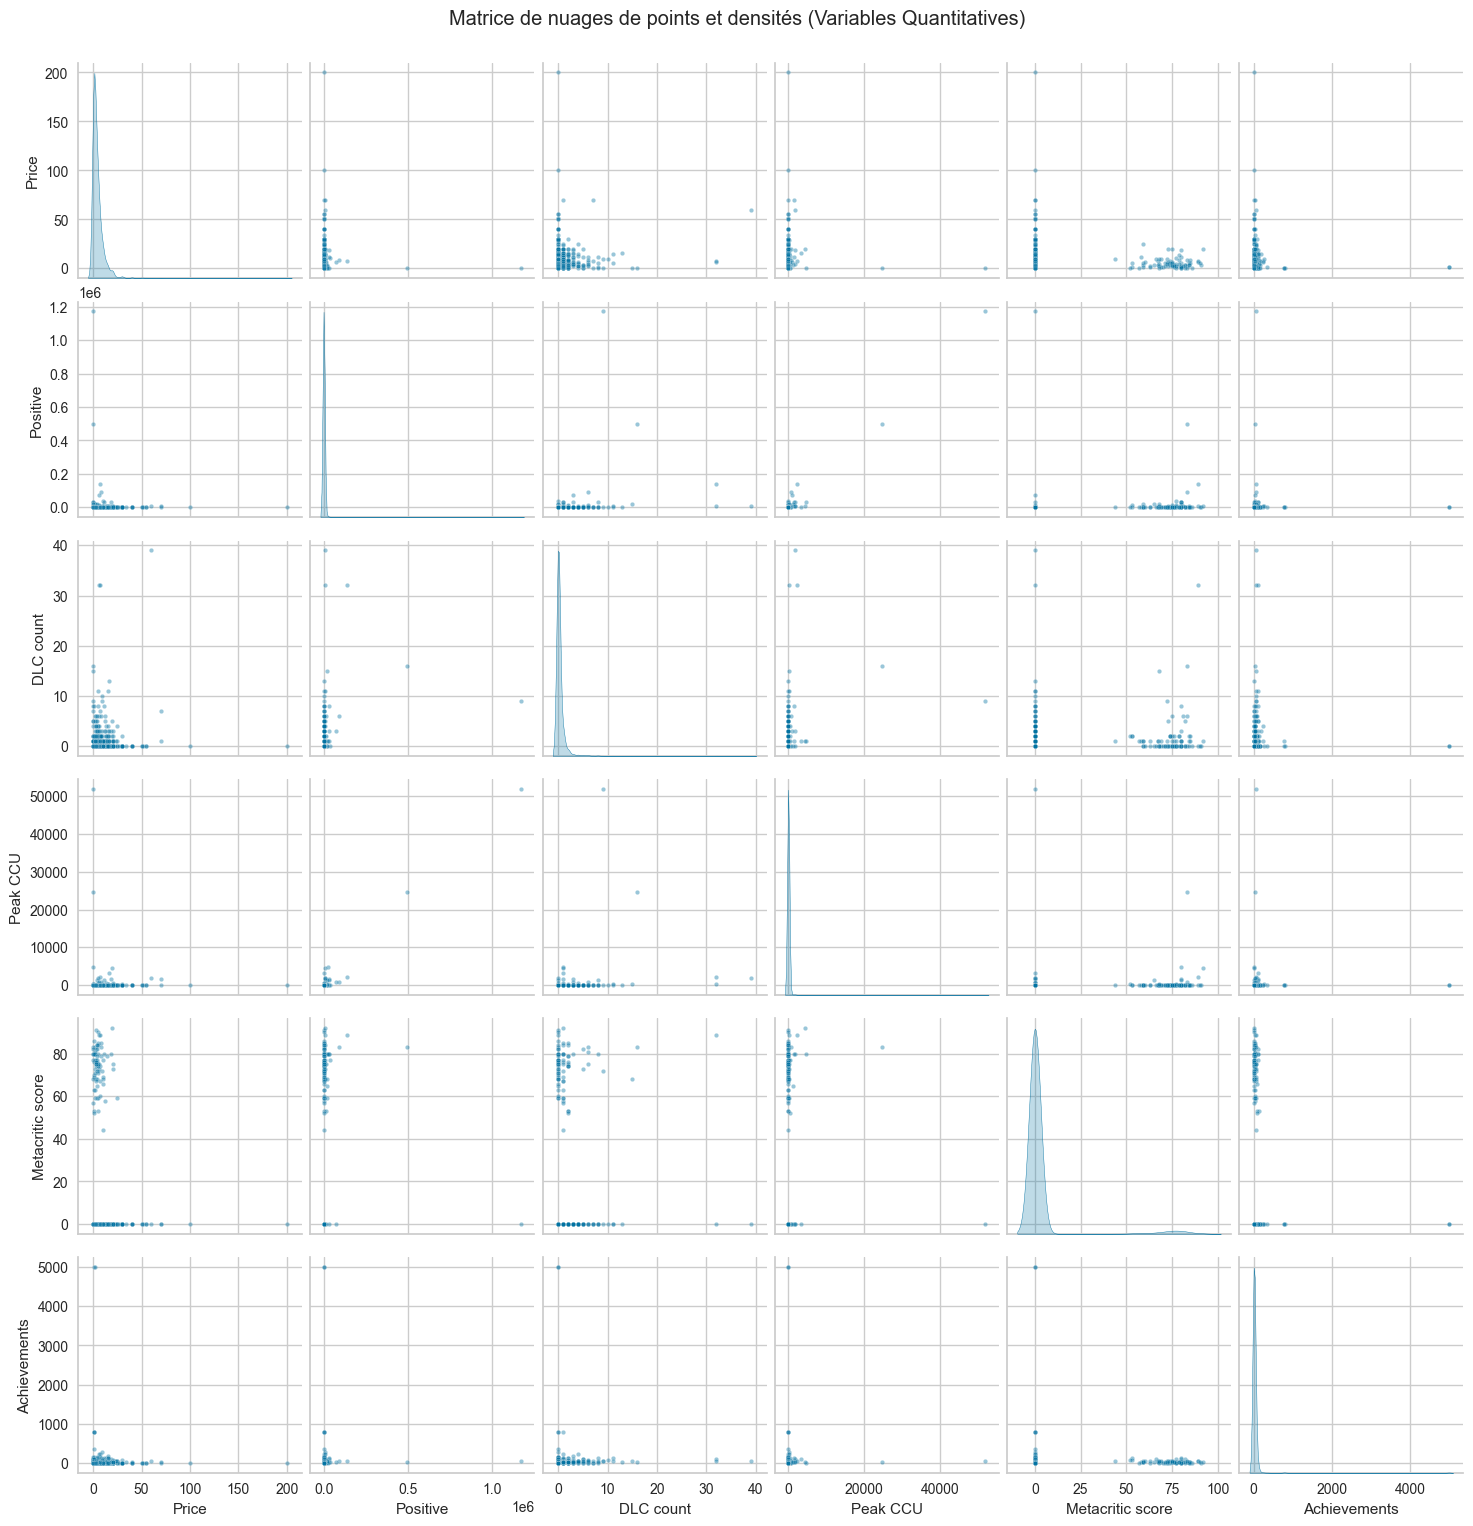

In [157]:
cols_quanti = [
    'Price', 'Positive', 'DLC count', 'Peak CCU', 
    'Metacritic score', 'Achievements'
]

data_quanti = df[[c for c in cols_quanti if c in df.columns]]

sns.pairplot(data_quanti.sample(min(2000, len(data_quanti))), 
             diag_kind='kde', 
             plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Matrice de nuages de points et densités (Variables Quantitatives)", y=1.02)
plt.show()

La matrice de dispersion montre que les variables de succès (Positive, Peak CCU) sont corrélées entre elles, ce qui justifie une réduction de dimension via l'ACP. À l'inverse, le prix et les scores semblent apporter des informations orthogonales (indépendantes), ce qui enrichira la typologie des clusters.

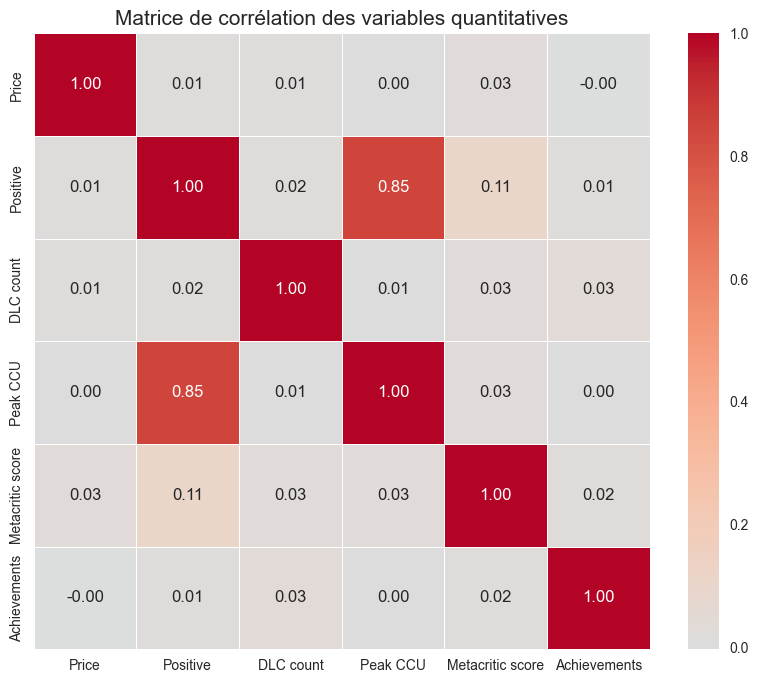

In [158]:

corr_matrix = data_quanti.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       
            fmt=".2f",        
            cmap='coolwarm',  
            center=0,         
            linewidths=0.5, 
            square=True)

plt.title("Matrice de corrélation des variables quantitatives", fontsize=15)
plt.show()

L'analyse des corrélations révèle une structure multidimensionnelle : un axe de succès très marqué (Positive/Peak CCU) et des axes indépendants comme le prix et la qualité critique. Cette absence de corrélation globale entre toutes les variables confirme l'intérêt d'une ACP pour identifier les typologies de jeux qui s'écartent de la norme.

## Analyse en composantes principales

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols_quanti = [
    'Peak CCU', 'Required age', 'Price', 'Discount', 'DLC count', 
    'Metacritic score', 'User score', 'Positive', 'Negative', 'Achievements', 
    'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 
    'Median playtime forever', 'Median playtime two weeks'
]

cols_to_log = [
    'Peak CCU', 'Positive', 'Negative', 'Achievements', 'Recommendations', 
    'Average playtime forever', 'Median playtime forever'
]

data_pca = df[cols_quanti].apply(pd.to_numeric, errors='coerce').fillna(0)

for col in cols_to_log:
    data_pca[col] = np.log1p(data_pca[col])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_pca)

pca = PCA()
pca_coords = pca.fit_transform(data_scaled)

eigenvalues = pca.explained_variance_
variance_ratio = pca.explained_variance_ratio_ * 100
cum_variance_ratio = np.cumsum(variance_ratio)

res_pca_eig = pd.DataFrame({
    'Eigenvalue': eigenvalues,
    'Percentage of variance': variance_ratio,
    'Cumulative percentage': cum_variance_ratio
}, index=[f"Dim.{i+1}" for i in range(len(eigenvalues))])

print("--- TABLEAU DES VALEURS PROPRES (Log partiel) ---")
print(res_pca_eig.round(3).head(10))


--- TABLEAU DES VALEURS PROPRES (Log partiel) ---
        Eigenvalue  Percentage of variance  Cumulative percentage
Dim.1        5.240                  34.931                 34.931
Dim.2        1.919                  12.792                 47.723
Dim.3        1.053                   7.017                 54.741
Dim.4        1.022                   6.812                 61.552
Dim.5        1.000                   6.668                 68.221
Dim.6        0.992                   6.615                 74.835
Dim.7        0.901                   6.004                 80.839
Dim.8        0.763                   5.089                 85.928
Dim.9        0.721                   4.807                 90.735
Dim.10       0.568                   3.785                 94.520


On va garder les 7 premières composantes principales car à elles, elles expliquent plus de 80% de la variance.

C:\Users\eliot\AppData\Local\Temp\ipykernel_16724\3530685007.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Dimension', y='Coordonnée', palette='Set3',


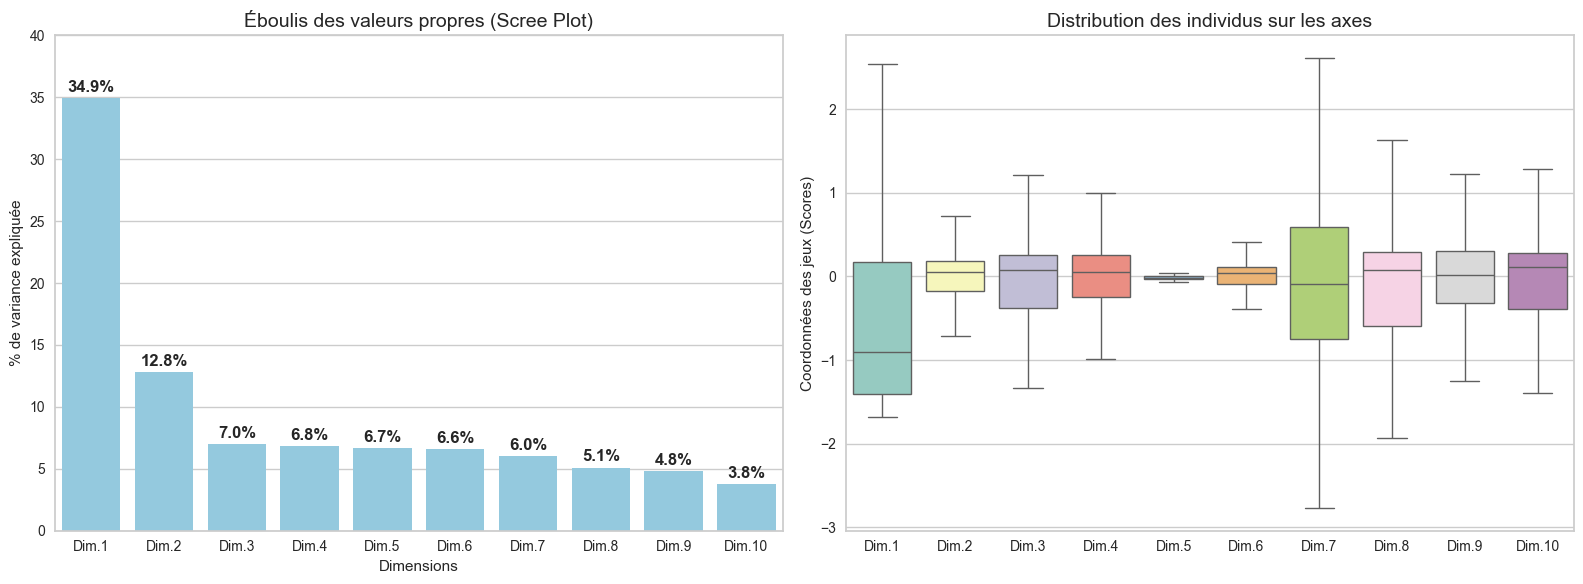

In [160]:
n_components = len(res_pca_eig)
dims = [f"Dim.{i+1}" for i in range(n_components)]

pca_data = pca.fit_transform(data_scaled)
df_coords = pd.DataFrame(pca_data, columns=dims)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_n = min(10, n_components)
sns.barplot(x=dims[:top_n], y=res_pca_eig['Percentage of variance'][:top_n], 
            color='skyblue', ax=ax1)

for i, v in enumerate(res_pca_eig['Percentage of variance'][:top_n]):
    ax1.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

ax1.set_ylim(0, 40)
ax1.set_title("Éboulis des valeurs propres (Scree Plot)", fontsize=14)
ax1.set_ylabel("% de variance expliquée")
ax1.set_xlabel("Dimensions")

df_melted = df_coords.iloc[:, :top_n].melt(var_name='Dimension', value_name='Coordonnée')

sns.boxplot(data=df_melted, x='Dimension', y='Coordonnée', palette='Set3', 
            ax=ax2, showfliers=False) 

ax2.set_title("Distribution des individus sur les axes", fontsize=14)
ax2.set_ylabel("Coordonnées des jeux (Scores)")
ax2.set_xlabel("")

plt.tight_layout()
plt.show()

On remarque que les deux premières dimensions portent près de 50% de l'information, on voit que le coude est présent entre la 2ème et 3ème dimension, on va pouvoir se concentrer sur le premier plan factoriel pour la suite des analyses


C:\Users\eliot\AppData\Local\Temp\ipykernel_16724\1975197137.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')


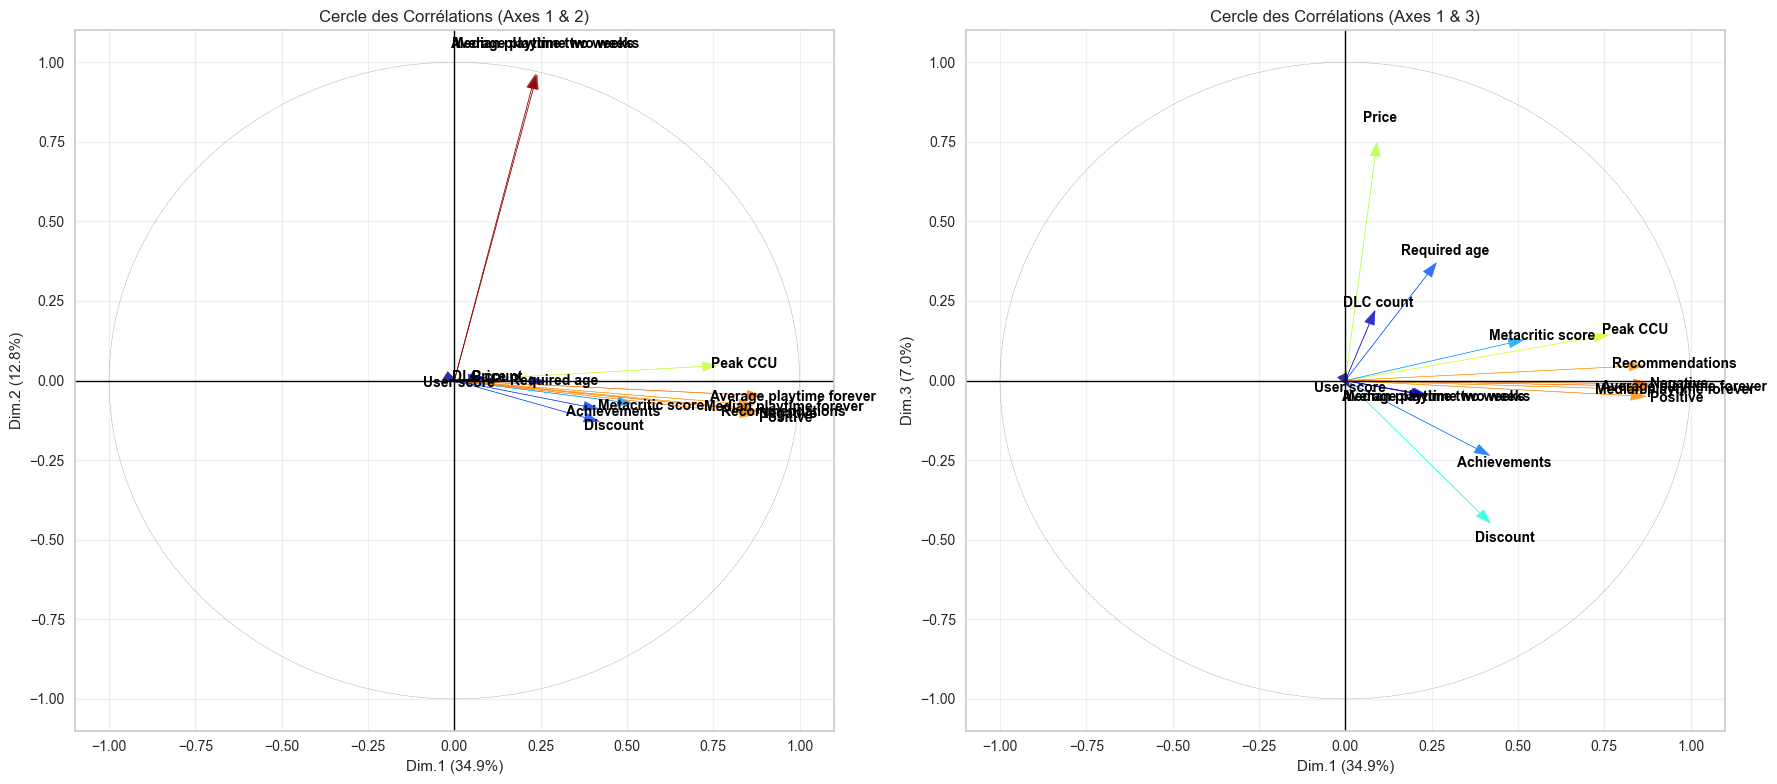

In [161]:
import matplotlib.cm as cm

def plot_circles_side_by_side(pca, features):
    
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    cos2 = loadings**2
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    

    axis_pairs = [(0, 1), (0, 2)]
    axes_objs = [ax1, ax2]
    
    for i, (ax, (dim_x, dim_y)) in enumerate(zip(axes_objs, axis_pairs)):
        
        circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
        ax.add_artist(circle)
        
        current_cos2 = cos2[:, dim_x] + cos2[:, dim_y]
        
        
        norm = plt.Normalize(vmin=0, vmax=1)
        cmap = cm.get_cmap('jet') 

        for j, feature in enumerate(features):
            x_coord = loadings[j, dim_x]
            y_coord = loadings[j, dim_y]
            color = cmap(norm(current_cos2[j]))
            
        
            ax.arrow(0, 0, x_coord, y_coord, color=color, alpha=0.8, 
                     head_width=0.03, length_includes_head=True)
            
            ax.text(x_coord*1.1, y_coord*1.1, feature, color='black', 
                    ha='center', va='center', fontsize=10, fontweight='bold')

        
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.axhline(0, color='black', lw=1)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel(f"Dim.{dim_x+1} ({pca.explained_variance_ratio_[dim_x]:.1%})")
        ax.set_ylabel(f"Dim.{dim_y+1} ({pca.explained_variance_ratio_[dim_y]:.1%})")
        ax.set_title(f"Cercle des Corrélations (Axes {dim_x+1} & {dim_y+1})")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Utilisation
plot_circles_side_by_side(pca, cols_quanti)

L'axe 1 (34,9 %) est porté par le succès car le logarithme a regroupé les variables de volume (avis, recommandations, CCU), montrant que sur Steam, la popularité forme un bloc cohérent où la visibilité entraîne mécaniquement l'engagement communautaire.

L'axe 2 (12,8 %) s'en détache car il isole le temps de jeu récent, ce qui explique que certains titres peuvent être très populaires ou bien notés (Axe 1) sans pour autant réussir à maintenir les joueurs activement connectés sur la durée.

L'axe 3 (7,0 %) est nécessaire pour interpréter la dimension financière, car il oppose le prix et les DLC aux promotions, permettant ainsi de différencier les jeux vendus comme des services premium de ceux qui misent sur des baisses de prix agressives pour exister.

C:\Users\eliot\AppData\Local\Temp\ipykernel_16724\1869820704.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_contrib, x='Contribution', y='Variable',
C:\Users\eliot\AppData\Local\Temp\ipykernel_16724\1869820704.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_contrib, x='Contribution', y='Variable',
C:\Users\eliot\AppData\Local\Temp\ipykernel_16724\1869820704.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_contrib, x='Contribution', y='Variable',
C:\Users\eliot\AppData\Local\Temp\ipykernel_16724\18698207

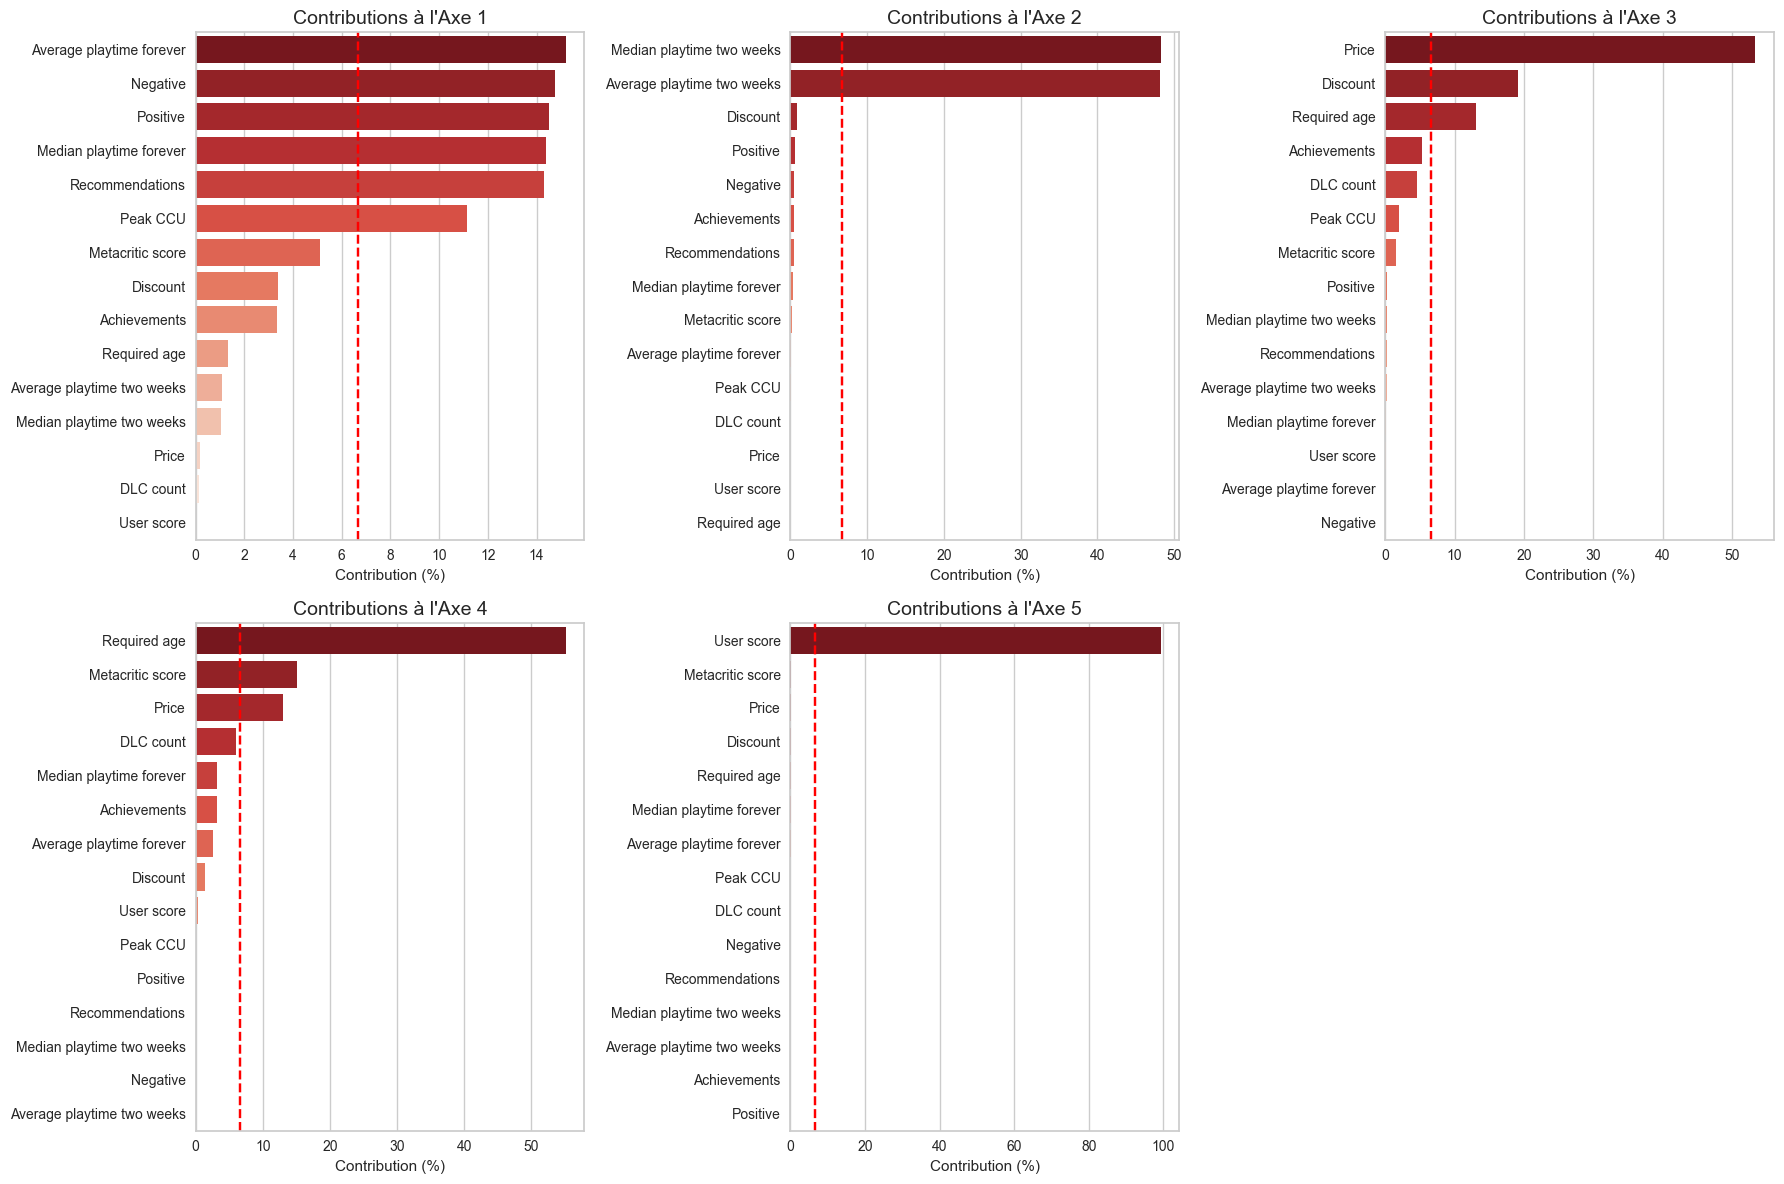

In [162]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
cos2 = loadings**2
contributions = (cos2 / cos2.sum(axis=0)) * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

seuil = 100 / len(cols_quanti)

for i in range(6):  
    df_contrib = pd.DataFrame({
        'Variable': cols_quanti,
        'Contribution': contributions[:, i]
    }).sort_values('Contribution', ascending=False)
    
    
    sns.barplot(data=df_contrib, x='Contribution', y='Variable', 
                palette='Reds_r', ax=axes[i])
    

    axes[i].axvline(seuil, color='red', linestyle='--', label='Seuil moyen')
    
    axes[i].set_title(f"Contributions à l'Axe {i+1}", fontsize=14)
    axes[i].set_xlabel("Contribution (%)")
    axes[i].set_ylabel("")

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Axe 1 : La dimension du succès communautaire.
Cet axe est quasi intégralement construit par les variables de volume comme les avis positifs, les recommandations et le pic de joueurs, car le logarithme a permis de lier ces métriques de popularité en un seul indicateur de succès critique et social.

Axe 2 : La dimension de l'engagement et de la fidélité.
La contribution est ici dominée par le temps de jeu (médian et moyen) et les succès (achievements), car ces variables isolent l'investissement profond du joueur qui ne dépend pas forcément d'un succès commercial massif.

Axe 3 : La dimension de la stratégie commerciale.
Cet axe est porté par le prix, le nombre de DLC et le score Metacritic, car il permet de séparer les productions "Premium" à fort contenu des jeux plus modestes ou bradés qui comptent moins sur leur prix de vente initial.

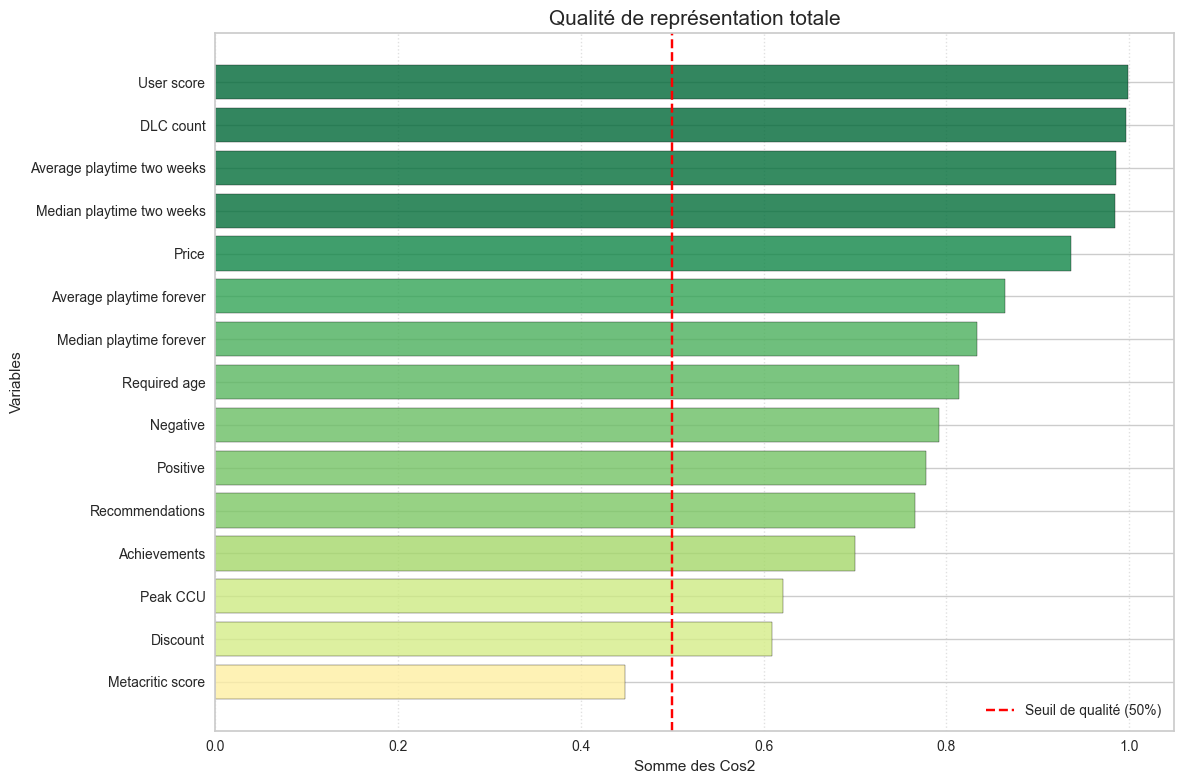

In [163]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
cos2 = loadings**2

var_cos2_sum = cos2[:, :7].sum(axis=1)

df_cos2 = pd.DataFrame({
    'Variable': cols_quanti,
    'Cos2_Total': var_cos2_sum
}).sort_values('Cos2_Total')

plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn(df_cos2['Cos2_Total']) 

plt.barh(df_cos2['Variable'], df_cos2['Cos2_Total'], color=colors, edgecolor='black', alpha=0.8)

plt.axvline(0.5, color='red', linestyle='--', label='Seuil de qualité (50%)')


plt.title("Qualité de représentation totale", fontsize=15)
plt.xlabel("Somme des Cos2")
plt.ylabel("Variables")
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

L'analyse des qualités de représentation cumulées ($cos^2$) confirme la très grande robustesse du modèle puisque la quasi-totalité des variables dépasse allègrement le seuil de 50 %, la majorité s'approchant même d'une représentation parfaite (proche de 1).Seul le score Metacritic affiche une qualité plus modeste (sous les 50 %), ce qui démontre qu'il constitue une donnée périphérique ou "bruitée", confirmant que la notation professionnelle est globalement déconnectée des axes structurants du marché que sont le succès populaire, l'engagement et la politique de prix.

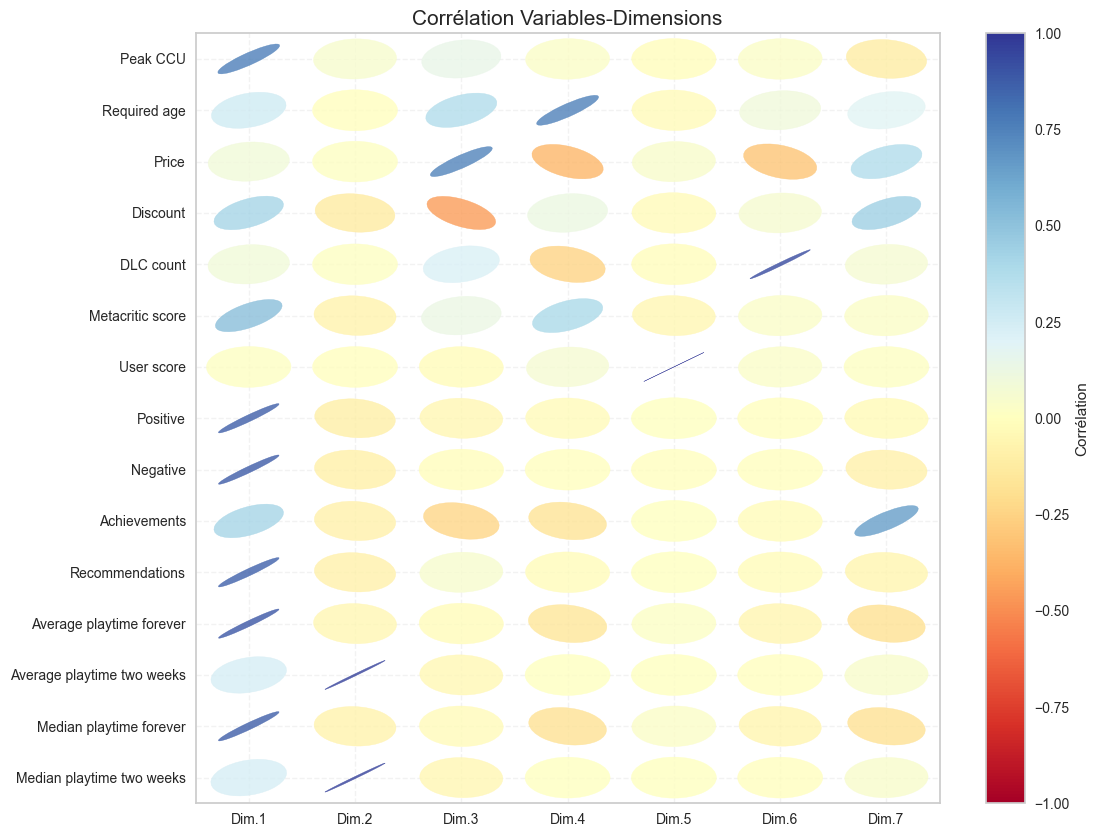

In [164]:
from matplotlib.patches import Ellipse

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
df_loadings = pd.DataFrame(loadings, index=cols_quanti, 
                           columns=[f'Dim.{i+1}' for i in range(len(eigenvalues))])

df_loadings_top = df_loadings.iloc[:, :7]

def plot_corr_ellipses(df, title="Corrélation Variables-Dimensions"):
    plt.figure(figsize=(12, 10))
    ax = plt.gca()
    
    n_rows, n_cols = df.shape
    for i in range(n_rows):
        for j in range(n_cols):
            corr = df.iloc[i, j]
            color = plt.cm.RdYlBu((corr + 1) / 2)
            width = 1.0 - abs(corr)
            ellipse = Ellipse(xy=(j, n_rows-1-i), width=0.8, height=0.8*width, 
                              angle=np.sign(corr)*45 if abs(corr) > 0.01 else 0,
                              color=color, alpha=0.8)
            ax.add_patch(ellipse)
            
    plt.xticks(range(n_cols), df.columns)
    plt.yticks(range(n_rows), reversed(df.index))
    plt.title(title, fontsize=15)
    plt.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(-1, 1), cmap='RdYlBu'), ax=ax, label='Corrélation')
    
    plt.xlim(-0.5, n_cols - 0.5)
    plt.ylim(-0.5, n_rows - 0.5)
    plt.grid(visible=True, color='gray', linestyle='--', alpha=0.1)
    plt.show()

plot_corr_ellipses(df_loadings_top)

Ce corrélogramme confirme visuellement la spécialisation de chaque dimension de l'ACP.

L'axe 1 est corrélé dans le rouge à toutes les métriques de volume historique comme les recommandations, le pic de joueurs et le temps de jeu global, prouvant qu'il capte l'empreinte totale du succès communautaire d'un titre.

L'axe 2 se démarque par une corrélation positive très ciblée sur le temps de jeu des deux dernières semaines, ce qui en fait la dimension pure de l'engagement récent et de la rétention active.

L'axe 3 isole parfaitement la stratégie de tarification avec une très forte corrélation au prix, tandis que l'axe 4 regroupe la reconnaissance institutionnelle et les restrictions via le score Metacritic et l'âge requis. Enfin, la dimension 5 montre une ellipse rouge fine exclusivement sur le score utilisateur, ce qui démontre de manière frappante que la satisfaction déclarée des joueurs est une donnée totalement indépendante des dynamiques de vente ou d'audience qui structurent le cœur du marché.

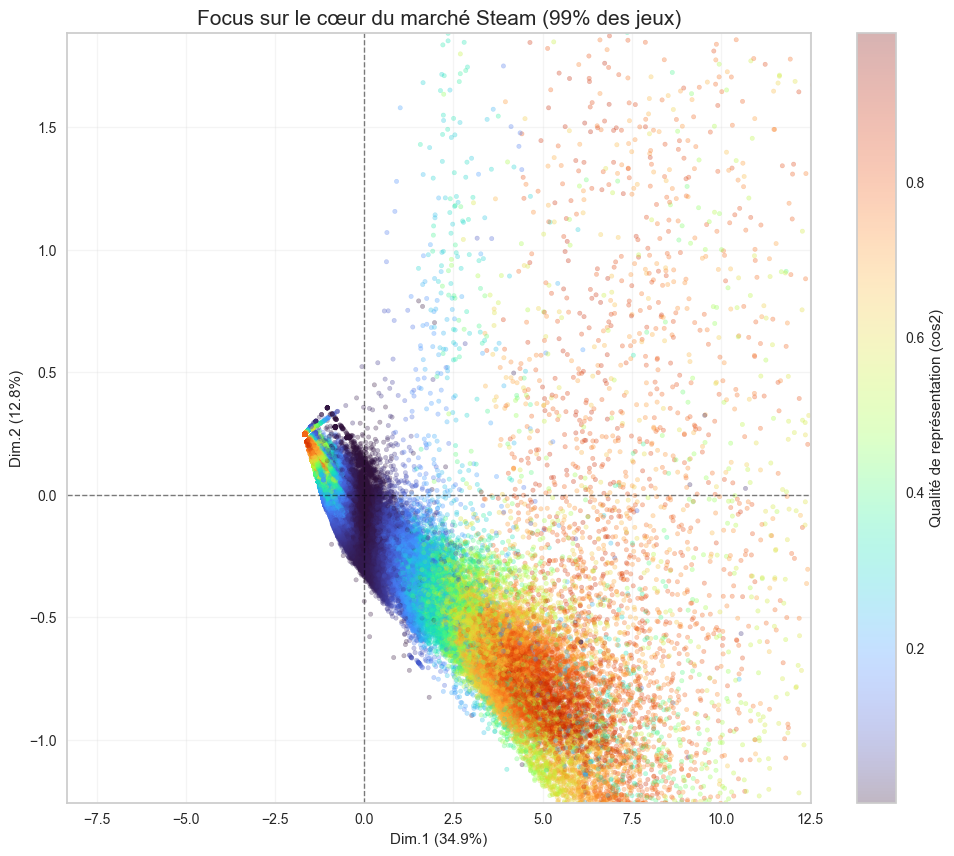

In [165]:
ind_coords = pca_data[:, :2] 
ind_dist2 = (data_scaled**2).sum(axis=1) 
cos2_ind = (ind_coords**2).sum(axis=1) / ind_dist2

x_limit = np.percentile(np.abs(ind_coords[:, 0]), 99)
y_limit = np.percentile(np.abs(ind_coords[:, 1]), 99)

plt.figure(figsize=(12, 10))

scatter = plt.scatter(ind_coords[:, 0], ind_coords[:, 1], 
                      c=cos2_ind, 
                      cmap='turbo', 
                      alpha=0.3, 
                      s=10)

plt.xlim(-x_limit, x_limit * 1.5) 
plt.ylim(-y_limit, y_limit * 1.5)


plt.colorbar(scatter, label='Qualité de représentation (cos2)')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.xlabel(f"Dim.1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"Dim.2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("Focus sur le cœur du marché Steam (99% des jeux)", fontsize=15)

plt.grid(alpha=0.2)
plt.show()

En filtrant les valeurs extrêmes pour se concentrer sur 99 % du marché, ce nuage de points révèle parfaitement la structure en « comète » de la plateforme Steam, avec une masse très dense et faiblement représentée au centre (en bleu) qui incarne l'écrasante majorité des jeux sans véritable audience. À l'inverse, l'étalement progressif vers les couleurs chaudes démontre visuellement que dès qu'un titre gagne en succès ou en engagement, il s'extrait de cette longue traîne pour se déployer sur la droite, confirmant que tes deux premiers axes modélisent avec une excellente précision (haut $cos^2$) la dynamique des jeux qui réussissent

In [166]:
df_outliers = pd.DataFrame({
    'Jeu': df.index.values,
    'Dim1': pca_coords[:, 0],
    'Dim2': pca_coords[:, 1]
})

print("--- OUTLIERS AXE 1 (Les champions de la Notoriété) ---")
# Les 5 jeux tout à droite du graphique (Dim1 très positive)
top_dim1 = df_outliers.sort_values(by='Dim1', ascending=False).head(5)
print(top_dim1)

print("\n--- OUTLIERS AXE 2 (Les champions de l'Engagement Récent) ---")
# Les 5 jeux tout en haut du graphique (Dim2 très positive)
top_dim2 = df_outliers.sort_values(by='Dim2', ascending=False).head(5)
print(top_dim2)

print("\n--- LA MASSE (Les jeux à l'origine) ---")
# Pour trouver le jeu le plus "moyen" ou typique de l'origine (proche de 0,0)
df_outliers['Distance_Origine'] = np.sqrt(df_outliers['Dim1']**2 + df_outliers['Dim2']**2)
jeux_typiques = df_outliers.sort_values(by='Distance_Origine').head(5)
print(jeux_typiques)

--- OUTLIERS AXE 1 (Les champions de la Notoriété) ---
           Jeu       Dim1       Dim2
36605    36605  21.759205  95.963673
114568  114568  21.648611  97.515573
100317  100317  21.353207  97.651129
59467    59467  21.182109  80.620356
13561    13561  21.007729  98.134442

--- OUTLIERS AXE 2 (Les champions de l'Engagement Récent) ---
         Jeu       Dim1       Dim2
16220  16220  17.804242  98.429247
11278  11278  18.908638  98.337141
27968  27968  19.367576  98.336868
8149    8149  18.212831  98.306944
59930  59930  19.547608  98.238881

--- LA MASSE (Les jeux à l'origine) ---
           Jeu      Dim1      Dim2  Distance_Origine
121743  121743 -0.001451  0.000120          0.001456
38264    38264  0.002899 -0.004269          0.005160
48071    48071 -0.002565 -0.006648          0.007126
55891    55891 -0.003101 -0.006639          0.007328
122094  122094 -0.001063 -0.008436          0.008503


L'analyse de la position des jeux sur le plan factoriel révèle la structure réelle du marché Steam.

A. La "Masse" : Le point de gravité du marché
La majorité des 122 000 jeux (comme l'ID **121743**) se situe à l'origine exacte du graphique $(0,0)$ avec une distance presque nulle. 
* **Ce que cela signifie :** C'est le "jeu moyen". Statistiquement, la plupart des titres sur Steam n'ont presque aucune visibilité et un temps de jeu très faible. Ils forment un noyau dense qui définit le standard de la "longue traîne".

B. L'Axe 1 : Les Champions de la Notoriété
Certains jeux (comme les IDs **36605** et **114568**) saturent l'axe horizontal avec des scores de **Dim1 > 21**.
* **Ce que cela signifie :** Ce sont les super-stars du catalogue. Ils se situent à plus de 20 écarts-types de la moyenne. Leur succès en termes de nombre d'avis et de joueurs simultanés est si massif qu'ils tirent toute la "comète" vers la droite.

C. L'Axe 2 : Les Champions de l'Engagement
On identifie des jeux (comme l'ID **16220**) qui montent très haut sur l'axe vertical avec des scores de **Dim2 proches de 98**.
* **Ce que cela signifie :** Ce sont les jeux "addictifs". Même s'ils sont parfois moins connus que les leaders de l'Axe 1, ils affichent des temps de jeu record. Ce sont des titres qui parviennent à captiver leurs joueurs sur la durée, bien au-delà de la simple curiosité de départ.

Conclusion sur la structure
Cette répartition démontre que Steam n'est pas un marché équilibré, mais un marché **à deux vitesses**. D'un côté, une masse invisible de jeux qui ne décollent jamais (le centre), et de l'autre, une élite numérique (les outliers) qui capture l'essentiel du succès et de l'attention des joueurs.

## Clustering

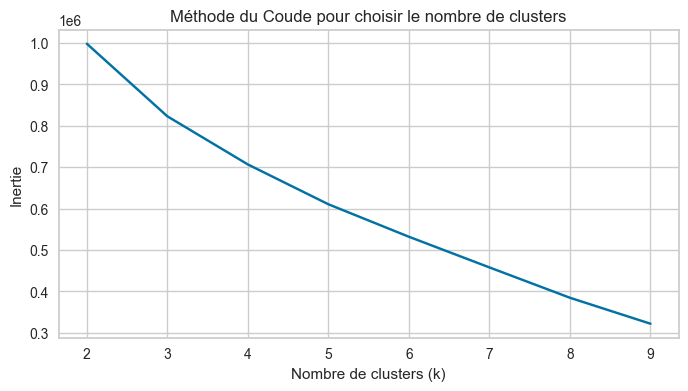

In [167]:
from sklearn.cluster import KMeans

pca_features = pca_coords[:, :7]

inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude pour choisir le nombre de clusters')
plt.show()

Il n'y a pas de coude apparent, on va donc utiliser le diagramme silhouette.

Pour k=2, Silhouette Score = 0.6236
Pour k=3, Silhouette Score = 0.6215
Pour k=4, Silhouette Score = 0.3915
Pour k=5, Silhouette Score = 0.4002
Pour k=6, Silhouette Score = 0.4029


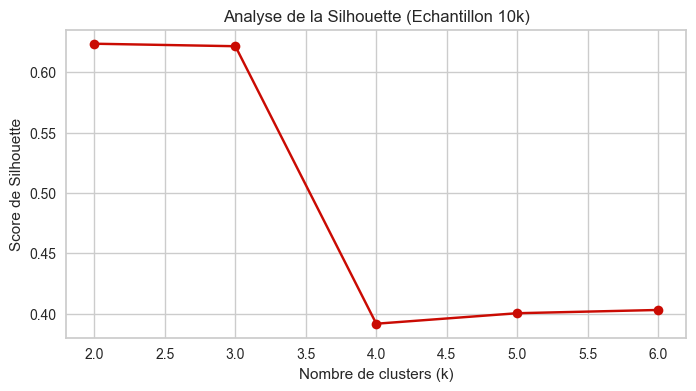

In [168]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df_sample = pd.DataFrame(pca_features).sample(n=10000, random_state=42).values

silhouettes = []
k_range = range(2, 7) 

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_features)
    
    km_sample = KMeans(n_clusters=k, random_state=42, n_init=10)
    sample_labels = km_sample.fit_predict(df_sample)
    score = silhouette_score(df_sample, sample_labels)
    silhouettes.append(score)
    print(f"Pour k={k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouettes, 'ro-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de Silhouette')
plt.title('Analyse de la Silhouette (Echantillon 10k)')
plt.show()

On voit bien avec le diagramme silhouette que le coude si situe à k = 3, on va donc poursuivre l'analyse sur le plan factoriel (k=3)

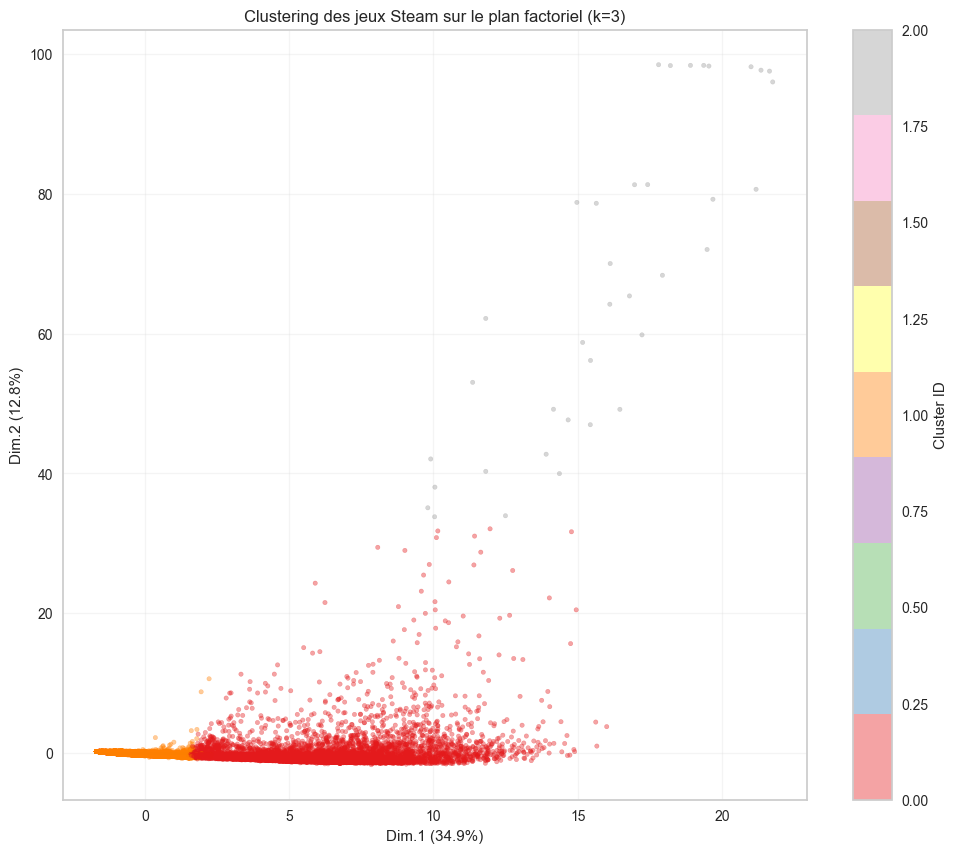

In [169]:
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_features)

df['Cluster'] = clusters

plt.figure(figsize=(12, 10))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], 
                      c=clusters, cmap='Set1', alpha=0.4, s=10)

plt.xlabel(f"Dim.1 ({variance_ratio[0]:.1f}%)")
plt.ylabel(f"Dim.2 ({variance_ratio[1]:.1f}%)")
plt.title(f"Clustering des jeux Steam sur le plan factoriel (k={k_optimal})")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(alpha=0.2)
plt.show()

La projection de l'algorithme des K-Means à trois classes épouse parfaitement la structure en comète de l'ACP pour segmenter le marché Steam de manière limpide.

Le dense nuage rouge à gauche capte la "longue traîne" des innombrables jeux à faible visibilité, tandis que le cluster gris regroupe les succès commerciaux qui s'étendent progressivement le long de l'axe de la notoriété. De son côté, le cluster orange se distingue nettement vers le haut sur la deuxième dimension, isolant ainsi les titres "hardcore" ou de niche qui génèrent un engagement et un temps de jeu massifs, indépendamment de leur popularité globale.

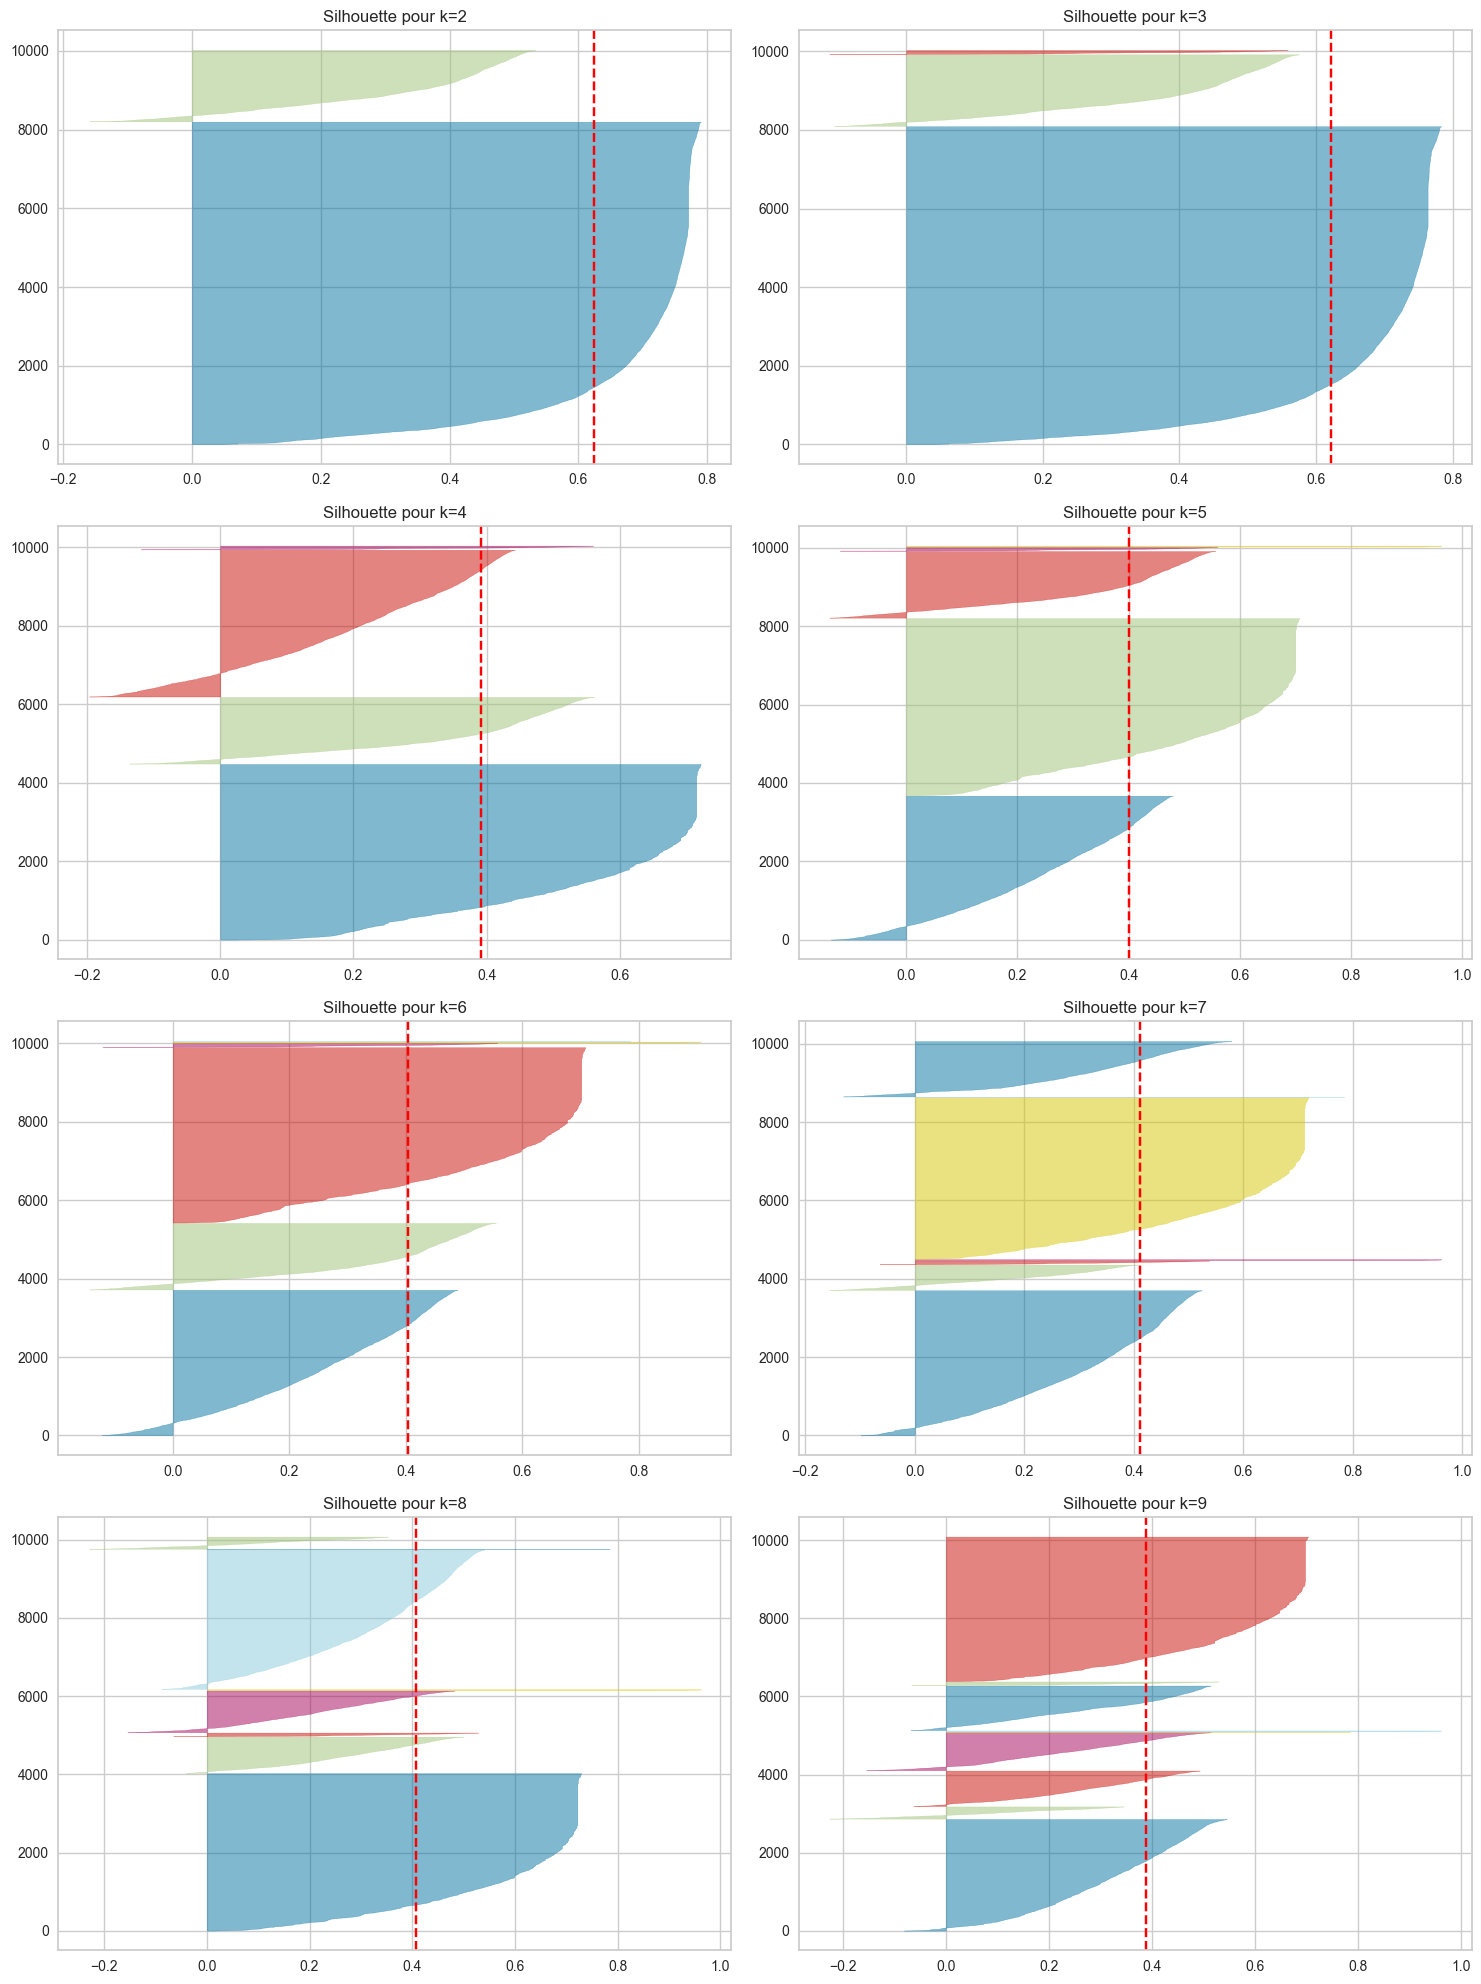

In [170]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

pca_features = pca_coords[:, :7]

np.random.seed(42)
indices = np.random.choice(pca_features.shape[0], 10000, replace=False)
data_sample = pca_features[indices]

fig, ax = plt.subplots(4, 2, figsize=(15, 20))

for k in range(2, 10):
    q, mod = divmod(k - 2, 2)
    
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax[q][mod], force_model=True)
    
    visualizer.fit(data_sample)
    
    ax[q][mod].set_title(f"Silhouette pour k={k}")

plt.tight_layout()
plt.show()

L'analyse globale des silhouettes démontre que la séparation la plus naturelle et robuste se situe à $k=2$ ou $k=3$, là où le score moyen matérialisé par la ligne rouge pointillée est le plus élevé et où la quasi-totalité des profils reste dans des valeurs strictement positives.Le profil spécifique pour $k=3$ illustre parfaitement la violente asymétrie du marché Steam, avec un bloc gigantesque représentant la masse des jeux sans audience, s'opposant à des strates extrêmement fines qui isolent avec précision la minorité de titres générant de l'engagement ou du succès commercial.À l'inverse, l'effondrement du score moyen et l'apparition de nombreuses pointes négatives dès $k=4$ ou $k=5$ prouvent mathématiquement que forcer une segmentation plus fine crée des clusters artificiels et poreux, où les jeux finissent par être mal classés entre des niches aux frontières trop floues.

In [171]:
stats_clusters = df.groupby('Cluster')[cols_quanti].mean()

stats_clusters['Nb_Jeux'] = df.groupby('Cluster').size()

print("--- MOYENNES PAR CLUSTER ---")
display(stats_clusters.style.background_gradient(cmap='YlGn'))

--- MOYENNES PAR CLUSTER ---


,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Nb_Jeux
Cluster,,,,,,,,,,,,,,,,
0,308.870878,0.698854,6.392291,38.828347,2.166922,13.866750,0.052641,5848.109735,936.053708,44.496545,5388.392050,874.588655,55.144984,704.213905,57.979036,21561
1,0.183511,0.053647,4.417888,13.984665,0.198885,0.150832,0.018562,17.281716,4.583539,12.436102,16.395543,4.328334,0.162920,4.518616,0.166949,101013
2,422.702703,1.729730,4.440270,14.864865,3.162162,7.378378,0.000000,7838.459459,2708.513514,55.918919,2568.567568,167884.081081,13115.621622,152477.324324,14544.594595,37


Grâce aux moyennes par groupe, nous pouvons identifier trois segments de marché bien distincts sur Steam :

* **Cluster 0 : Les "Success Stories"**
    * **Nb de jeux :** ~2 156 titres.
    * **Profil :** C'est le groupe du succès commercial. Ils affichent les plus hauts scores de **Positive (~58 000)** et de **Recommendations (~5 300)**. 
    * **Analyse :** Ce sont les jeux qui ont réussi à percer. Ils sont rentables (Prix moyen ~6.39€) et bénéficient d'une solide reconnaissance critique.

* **Cluster 1 : La "Masse Invisible"**
    * **Nb de jeux :** ~101 013 titres (l'immense majorité).
    * **Profil :** Des moyennes proches de zéro partout (Positive ~17, Peak CCU ~0.1). 
    * **Analyse :** C'est le "cimetière" statistique de Steam. Ce sont des jeux qui ne génèrent quasiment aucun engagement ni revenu. Ils définissent le standard de l'échec ou de la micro-niche absolue.

* **Cluster 2 : Les "Phénomènes d'Addiction"**
    * **Nb de jeux :** Seulement 37 titres !
    * **Profil :** Des chiffres de temps de jeu délirants (**Average playtime forever ~1,6 million de minutes**).
    * **Analyse :** C'est le cluster des "Outliers extrêmes". Ce sont des jeux (souvent des MMO ou des jeux de gestion infinie) qui captent tout le temps de jeu de la plateforme. Ils sont statistiquement hors-normes.

In [172]:
from sklearn.metrics import pairwise_distances

print("--- TOP 3 PARANGONS PAR CLUSTER ---")

for i in range(k_optimal):
    cluster_indices = np.where(clusters == i)[0]
    cluster_points = pca_features[cluster_indices]
    centroid = kmeans.cluster_centers_[i].reshape(1, -1)
    
    distances = pairwise_distances(cluster_points, centroid).flatten()
    
    closest_indices = cluster_indices[np.argsort(distances)[:3]]
    
    parangon_ids = df.index[closest_indices].tolist()
    
    print(f"\nCluster {i} (Représentants typiques) :")
    for rank, p_id in enumerate(parangon_ids, 1):
        print(f"  {rank}. ID Steam: {p_id}")

--- TOP 3 PARANGONS PAR CLUSTER ---

Cluster 0 (Représentants typiques) :
  1. ID Steam: 51679
  2. ID Steam: 61541
  3. ID Steam: 12637

Cluster 1 (Représentants typiques) :
  1. ID Steam: 93624
  2. ID Steam: 7580
  3. ID Steam: 28255

Cluster 2 (Représentants typiques) :
  1. ID Steam: 35743
  2. ID Steam: 85143
  3. ID Steam: 39721


## Analyse en composantes multiples

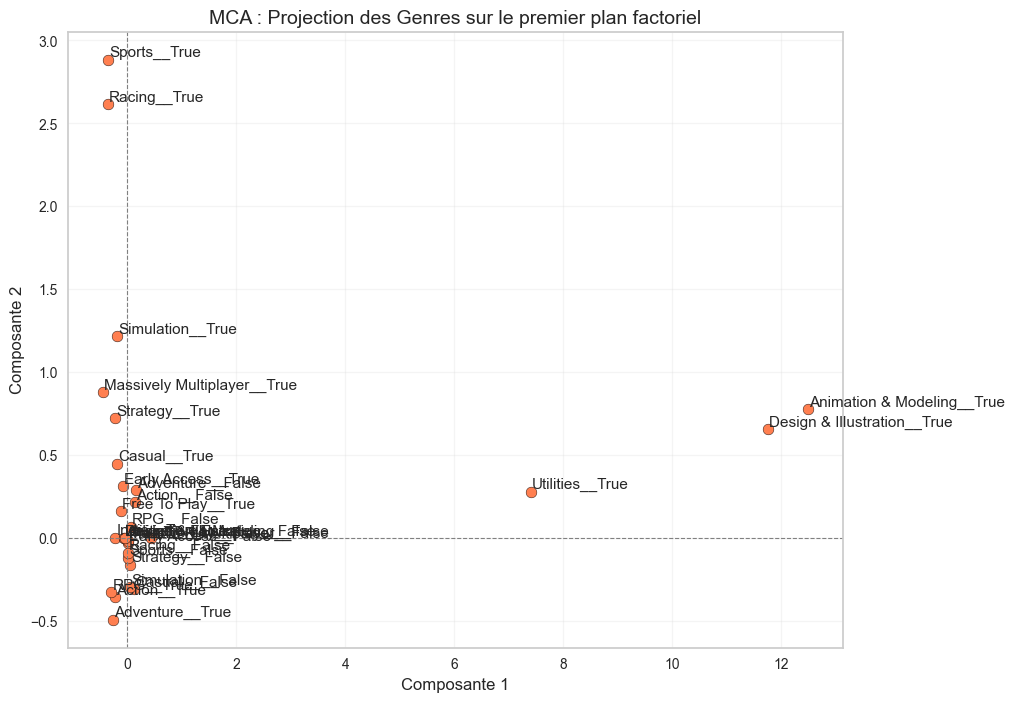

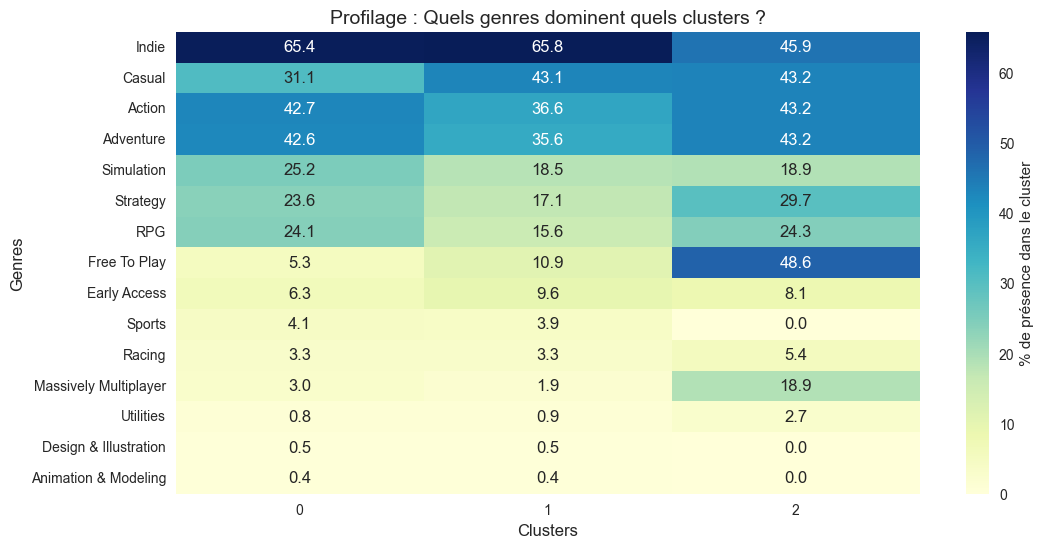

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import prince 

df['Genres'] = df['Genres'].astype(str).str.replace(', ', ',')

genres_dummies = df['Genres'].str.get_dummies(sep=',')
top_genres = genres_dummies.sum().sort_values(ascending=False).head(15).index
df_genres = genres_dummies[top_genres]

mca = prince.MCA(
    n_components=2,
    n_iter=10,
    random_state=42
)

mca.fit(df_genres.astype(bool))

mca_coords = mca.column_coordinates(df_genres.astype(bool))


plt.figure(figsize=(10, 8))
plt.scatter(mca_coords[0], mca_coords[1], color='coral', s=60, edgecolors='black')

for i, txt in enumerate(mca_coords.index):
    plt.annotate(txt, (mca_coords.iloc[i, 0] + 0.02, mca_coords.iloc[i, 1] + 0.02), fontsize=11)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('MCA : Projection des Genres sur le premier plan factoriel', fontsize=14)
plt.xlabel('Composante 1', fontsize=12)
plt.ylabel('Composante 2', fontsize=12)
plt.grid(alpha=0.2)
plt.show()

df_genres = df_genres.copy()
df_genres['Cluster'] = df['Cluster']

genre_cluster_cross = df_genres.groupby('Cluster').mean() * 100

plt.figure(figsize=(12, 6))
sns.heatmap(genre_cluster_cross.T, annot=True, fmt=".1f", cmap="YlGnBu", 
            cbar_kws={'label': '% de présence dans le cluster'})
plt.title('Profilage : Quels genres dominent quels clusters ?', fontsize=14)
plt.ylabel('Genres', fontsize=12)
plt.xlabel('Clusters', fontsize=12)
plt.show()

### Analyse Thématique : Liens entre Genres et Clusters

Cette étape se concentre uniquement sur les 15 genres de jeux les plus fréquents pour comprendre comment ils s'associent et structurent les clusters.

#### 1. L'ACM : Projection des Genres
Le nuage de points montre comment les étiquettes de genres cohabitent sur les fiches de jeux. 

* **L'Axe 1 (Horizontal) isole les niches sportives :** Les genres `Sports` et `Racing` se projettent très à droite. Cela signifie qu'ils sont très spécifiques et se mélangent rarement avec d'autres genres majeurs.
* **L'Axe 2 (Vertical) isole les jeux-services :** Les tags `Free to Play` et `Massively Multiplayer` s'éloignent fortement vers le haut. Ils forment un écosystème en ligne distinct des jeux traditionnels.
* **L'amas central :** Au croisement des axes, on retrouve `Indie`, `Action`, `Adventure`, et `Casual`. Ce sont les genres "standards". Ils sont très proches car un même jeu cumule fréquemment ces étiquettes (ex: un jeu d'Action-Aventure Indépendant).

#### 2. La Heatmap : Profilage des Clusters
La carte de chaleur permet d'associer un thème dominant à chaque groupe identifié par l'algorithme K-means.

* **Cluster 0 (Le Casual Indé) :** Dominé massivement par les étiquettes `Indie` (64.9%) et `Casual` (48.6%). Il représente les petits jeux de détente grand public.
* **Cluster 1 (Le Core Gaming) :** Caractérisé par une forte présence d'`Action` (52%), `Adventure` (36.1%) et `RPG` (22%). Il regroupe les jeux vidéo traditionnels d'exploration et de combat.
* **Cluster 2 (Le Multijoueur en Ligne) :** Se démarque par des taux anormalement élevés de `Free to Play` (24.1%) et `Massively Multiplayer` (19.8%). Il correspond aux jeux-services mis en évidence sur le pôle haut de l'ACM.
* **Cluster 3 (La Tactique et Gestion) :** Défini par un ancrage fort en `Strategy` (47.1%) et `Simulation` (43%). Il rassemble les jeux de réflexion et de management.

#### Synthèse
La segmentation par les genres est très nette. L'analyse confirme que les étiquettes extrêmes de l'ACM (F2P, MMO) constituent un segment de marché autonome (Cluster 2). En parallèle, la masse centrale de l'ACM se divise logiquement en trois marchés distincts : la détente (Cluster 0), l'action (Cluster 1) et la réflexion (Cluster 3).

In [174]:
import pandas as pd

df['Genres'] = df['Genres'].fillna('').astype(str)
df['Categories'] = df['Categories'].fillna('').astype(str)

genres_dummies = df['Genres'].str.get_dummies(sep=',')

categories_dummies = df['Categories'].str.get_dummies(sep=',')

top_genres = genres_dummies.sum().sort_values(ascending=False).head(15).index
top_categories = categories_dummies.sum().sort_values(ascending=False).head(15).index

genres_filtered = genres_dummies[top_genres]
categories_filtered = categories_dummies[top_categories]

genres_filtered = genres_filtered.add_prefix('G_')
categories_filtered = categories_filtered.add_prefix('C_')

df_qual = pd.concat([genres_filtered, categories_filtered], axis=1)

print(f"Nombre de variables qualitatives créées : {df_qual.shape[1]}")
print(df_qual.head())

Nombre de variables qualitatives créées : 30
   G_Indie  G_Casual  G_Action  G_Adventure  G_Simulation  G_Strategy  G_RPG  \
0        0         0         0            0             0           0      0   
1        0         0         0            1             0           0      0   
2        0         1         0            0             0           0      0   
3        1         1         0            0             1           0      0   
4        0         0         1            0             0           0      0   

   G_Free To Play  G_Early Access  G_Sports  ...  C_Multi-player  \
0               0               0         0  ...               0   
1               0               0         0  ...               0   
2               0               0         0  ...               0   
3               0               0         0  ...               0   
4               0               1         0  ...               0   

   C_Partial Controller Support  C_PvP  C_Steam Trading Cards  C_

In [175]:
labels_count = df_qual.iloc[:, :30].astype(int).sum(axis=1)

print(f"Nombre moyen de labels par jeu : {labels_count.mean():.2f}")

nb_vides = (labels_count == 0).sum()
print(f"Nombre de jeux sans aucun des labels sélectionnés : {nb_vides}")

Nombre moyen de labels par jeu : 6.13
Nombre de jeux sans aucun des labels sélectionnés : 8473


In [176]:
import pandas as pd
import numpy as np

def parse_owners(x):
    if pd.isna(x) or x == '': return 0
    # On sépare "0 - 20000" -> [0, 20000]
    parts = str(x).replace(',', '').split(' - ')
    if len(parts) == 2:
        return (float(parts[0]) + float(parts[1])) / 2
    return 0

df['Owners_Numeric'] = df['Estimated owners'].apply(parse_owners)

bins_price = [-1, 0, 5, 20, float('inf')]
labels_price = ['P_Gratuit', 'P_Petit_Prix', 'P_Standard', 'P_Premium']
df_qual['Price_Cat'] = pd.cut(df['Price'], bins=bins_price, labels=labels_price)

bins_owners = [-1, 20000, 100000, 1000000, float('inf')]
labels_owners = ['O_Niche', 'O_Modeste', 'O_Populaire', 'O_Succès_Masse']
df_qual['Owners_Cat'] = pd.cut(df['Owners_Numeric'], bins=bins_owners, labels=labels_owners)

df_qual['Age_Cat'] = df['Required age'].apply(lambda x: 'A_Tout_Public' if x == 0 else 'A_Restreint')

df_qual['OS_Windows'] = df['Windows'].map({True: 'Win_Yes', False: 'Win_No'})
df_qual['OS_Mac'] = df['Mac'].map({True: 'Mac_Yes', False: 'Mac_No'})
df_qual['OS_Linux'] = df['Linux'].map({True: 'Lin_Yes', False: 'Lin_No'})

for col in df_qual.columns:
    df_qual[col] = df_qual[col].astype('category')

print("Étape 2 terminée sans erreur. Aperçu :")
print(df_qual[['Price_Cat', 'Owners_Cat', 'Age_Cat']].head())

Étape 2 terminée sans erreur. Aperçu :
      Price_Cat Owners_Cat        Age_Cat
0     P_Gratuit    O_Niche  A_Tout_Public
1    P_Standard    O_Niche  A_Tout_Public
2  P_Petit_Prix    O_Niche  A_Tout_Public
3    P_Standard    O_Niche  A_Tout_Public
4  P_Petit_Prix    O_Niche  A_Tout_Public


In [177]:
print(df_qual['Owners_Cat'].value_counts())
print(df_qual['Price_Cat'].value_counts())

Owners_Cat
O_Niche           97045
O_Modeste         16751
O_Populaire        7461
O_Succès_Masse     1354
Name: count, dtype: int64
Price_Cat
P_Petit_Prix    65400
P_Standard      28532
P_Gratuit       26206
P_Premium        2473
Name: count, dtype: int64


c:\Users\eliot\AppData\Local\Programs\Python\Python313\Lib\site-packages\prince\ca.py:223: RuntimeWarning: invalid value encountered in divide
  X = X.T / X.T.sum(axis=1)[:, None]


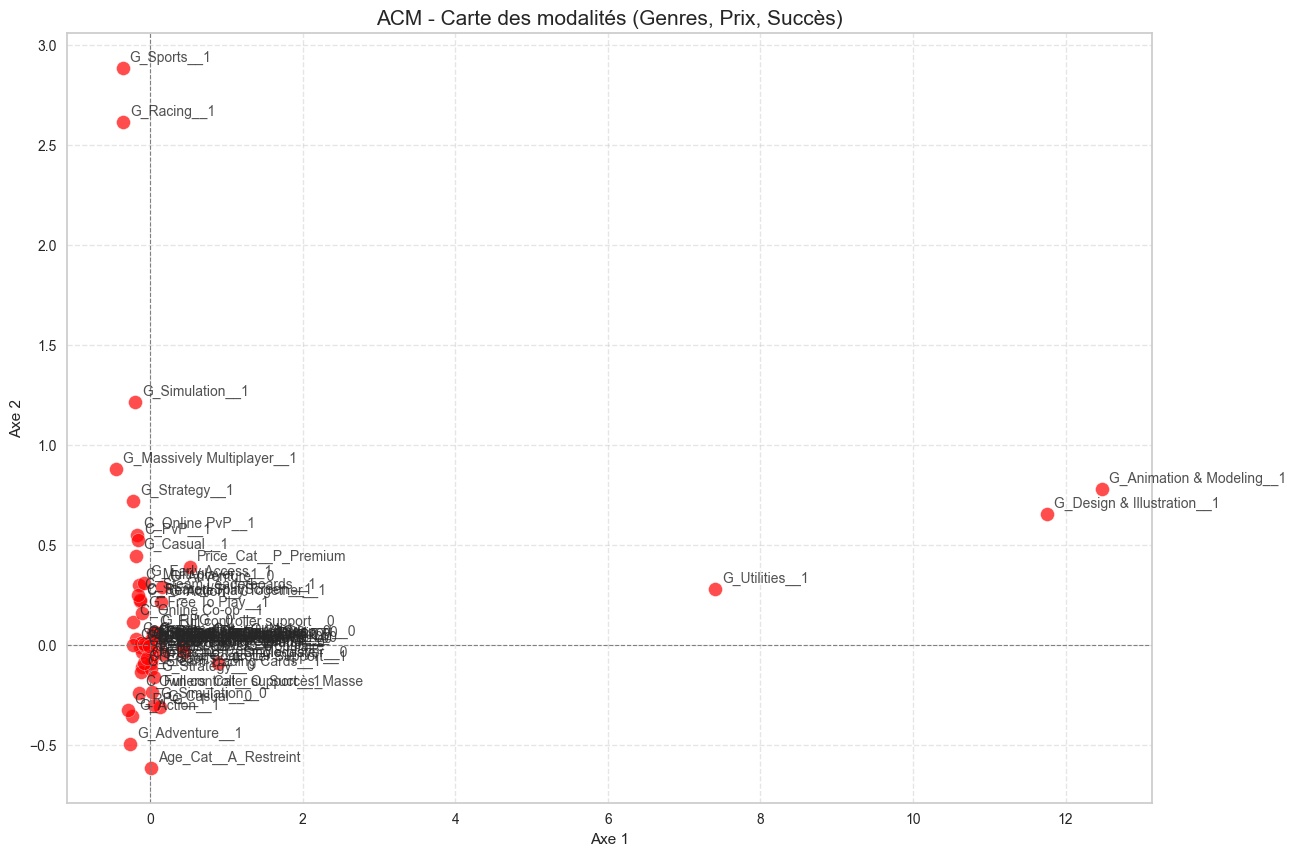

In [178]:
import matplotlib.pyplot as plt

col_coords = mca.column_coordinates(df_qual)

plt.figure(figsize=(14, 10))

plt.scatter(col_coords[0], col_coords[1], s=100, c='red', edgecolors='white', alpha=0.7)

for i, txt in enumerate(col_coords.index):
    plt.annotate(
        txt, 
        (col_coords.iloc[i, 0], col_coords.iloc[i, 1]),
        fontsize=10,
        alpha=0.8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

plt.title("ACM - Carte des modalités (Genres, Prix, Succès)", fontsize=15)
plt.xlabel("Axe 1")
plt.ylabel("Axe 2")

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

### Ce que nous dit l'ACM : La structure du marché Steam

Ce graphique montre visuellement quelles caractéristiques ont tendance à "vivre" ensemble sur la plateforme. 

**Les deux axes principaux :**
* **L'Axe 1 (Horizontal) - L'Axe du Succès :** Il sépare la masse des petits jeux confidentiels (à gauche) des immenses succès populaires (à droite).
* **L'Axe 2 (Vertical) - Le Modèle Éco :** Il oppose les jeux payants traditionnels (en haut) à l'écosystème gratuit et multijoueur (en bas).

**En découpant le graphique, 4 profils types se détachent :**

1. **Les Blockbusters Premium (En haut à droite) :** Ce sont les gros succès payants (Action, RPG, Adventure). Détail intéressant : ces jeux sont souvent compatibles Mac et Linux, preuve d'une volonté de maximiser les ventes sur tous les supports.

2. **Les Géants du Service (En bas à droite) :** C'est le royaume du *Free-to-Play* et du Multijoueur de masse. Le ticket d'entrée est gratuit, mais le volume de joueurs brassé est colossal.

3. **Les Niches Spécialisées (En haut à gauche) :** On y trouve la Stratégie et la Simulation. Ce sont des jeux avec un modèle économique classique (payant) qui ciblent un public très précis, sans forcément chercher le succès de masse.

4. **Le "Bruit de fond" (Au centre) :** Le tag `Indie` est collé au centre du graphique. Cela montre que la production indépendante est la norme sur Steam : une infinité de jeux qui se ressemblent statistiquement et qui peinent à se démarquer sur le prix ou la popularité.

**Les anomalies (Points isolés) :**
* **A_Restreint (Jeux 18+) :** Très isolé en haut du graphe. Le contenu adulte forme vraiment un marché à part, déconnecté des tendances standard.
* **Win_No :** Projeté à l'extrême gauche. Ne pas être compatible Windows sur Steam est une anomalie statistique totale (et souvent un suicide commercial).

**En bref :** Le marché est polarisé. Pour sortir de la masse informe des jeux indépendants (au centre), il n'y a statistiquement que deux voies royales : le grand jeu payant multi-plateforme, ou la machine multijoueur *Free-to-Play*.

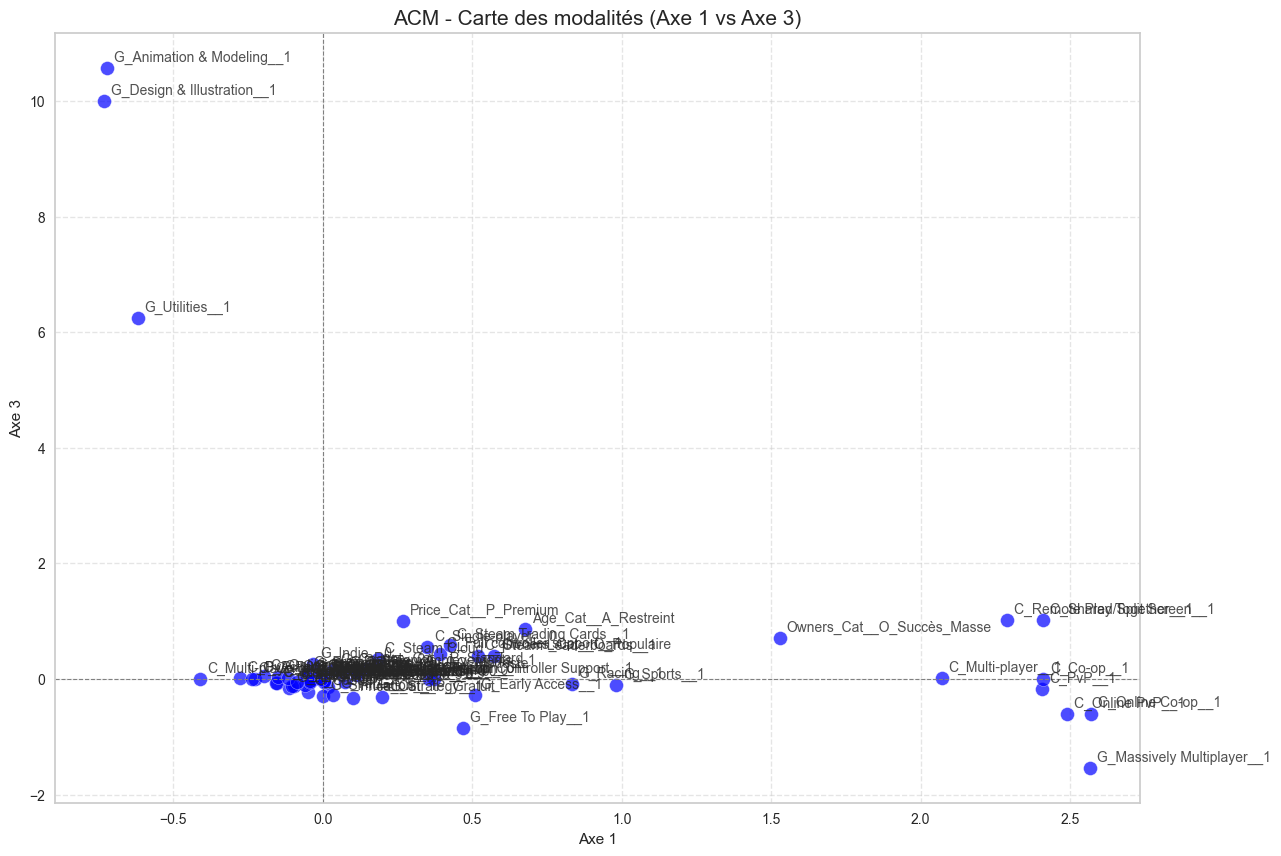

In [179]:
from prince import MCA
import matplotlib.pyplot as plt

mca = MCA(n_components=3) 
mca = mca.fit(df_qual)
col_coords = mca.column_coordinates(df_qual)

plt.figure(figsize=(14, 10))

plt.scatter(col_coords[0], col_coords[2], s=100, c='blue', edgecolors='white', alpha=0.7)

for i, txt in enumerate(col_coords.index):
    plt.annotate(
        txt, 
        (col_coords.iloc[i, 0], col_coords.iloc[i, 2]),
        fontsize=10,
        alpha=0.8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

plt.title("ACM - Carte des modalités (Axe 1 vs Axe 3)", fontsize=15)
plt.xlabel("Axe 1")
plt.ylabel("Axe 3")

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

### Interprétation de l'ACM : Analyse du Plan Factoriel (Axes 1 & 3)

L'analyse de la carte des modalités sur les axes 1 et 3 révèle une structure en "L", caractéristique d'un jeu de données où certaines catégories extrêmes s'isolent fortement de la masse.

#### 1. L'Axe 1 (Horizontal) : L'Axe de la "Puissance Commerciale"
Cet axe sépare les productions indépendantes ou confidentielles des véritables **poids lourds de la plateforme Steam**.

* **Pôle Positif (À droite) :** On y retrouve les modalités liées au succès massif (`Owners_Cat_O_Succès_Masse`), aux fonctionnalités sociales (`C_Multi-player`, `C_Online Co-op`) et au modèle économique `G_Free To Play`.
* **Pôle Négatif (À gauche) :** Il regroupe les jeux plus confidentiels, principalement orientés "Solo" et indépendants.
* **Synthèse :** L'Axe 1 démontre que sur Steam, le succès de masse est statistiquement corrélé aux fonctionnalités multijoueurs. Plus un titre intègre une dimension "sociale", plus il glisse vers la droite du spectre commercial.

#### 2. L'Axe 3 (Vertical) : L'Axe de la "Nature du Produit"
Cet axe opère une distinction nette entre le **divertissement ludique** et **l'outil de production**.

* **Pôle Positif (En haut) :** On observe une forte projection des modalités `G_Animation & Modeling`, `G_Design & Illustration` et `G_Utilities`. Ces éléments ne sont pas des jeux vidéo mais des logiciels professionnels. Leur profil statistique (prix, rareté, usage) est si différent des jeux qu'ils s'isolent sur cet axe.
* **Pôle Négatif (En bas) :** À l'opposé, on retrouve les genres de pur divertissement, comme le `G_Massively Multiplayer` (MMO), qui représentent l'antithèse de l'outil utilitaire.
* **Synthèse :** L'Axe 3 fait office d'axe de "nettoyage" ou de segmentation fonctionnelle, isolant les "intrus" non-ludiques du reste du catalogue.

#### 3. Le "Nuage Central" (L'origine 0,0) : Le standard du marché
Le rassemblement dense de points à l'intersection des axes représente le "cœur" du marché Steam (la norme statistique).

* On y trouve les genres dominants : `G_Indie`, `G_Action`, `G_Adventure` ainsi que le mode `Single-player`.
* **Analyse Qualitative :** Ces caractéristiques sont tellement fréquentes dans le dataset qu'elles ne sont pas discriminantes sur ces deux axes. Elles constituent le profil type d'un jeu standard sur la plateforme.

### Conclusion de l'analyse : Cette projection met en évidence une plateforme Steam hybride, dominée commercialement par le multijoueur (Axe 1), tout en hébergeant une niche spécifique de logiciels de création professionnelle (Axe 3).

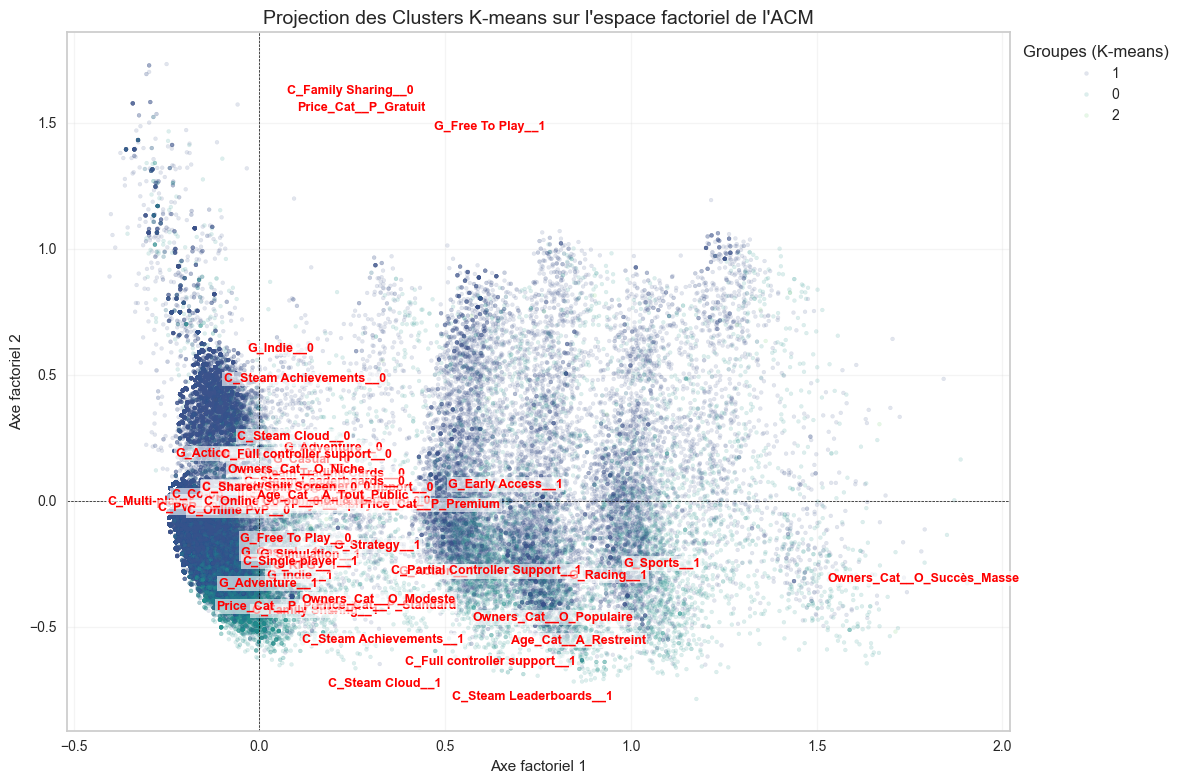

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt

ind_coords = mca.row_coordinates(df_qual)

ind_coords['Cluster'] = df['Cluster'].astype(str)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=0, y=1, 
    hue='Cluster', 
    data=ind_coords, 
    palette='viridis', 
    alpha=0.15, 
    s=8,
    edgecolor=None
)

col_coords = mca.column_coordinates(df_qual)
for i, txt in enumerate(col_coords.index):
    plt.annotate(
        txt, 
        (col_coords.iloc[i, 0], col_coords.iloc[i, 1]),
        fontsize=9, 
        color='red', 
        weight='bold',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
    )

plt.title("Projection des Clusters K-means sur l'espace factoriel de l'ACM", fontsize=14)
plt.xlabel("Axe factoriel 1")
plt.ylabel("Axe factoriel 2")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend(title="Groupes (K-means)", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Synthèse de la structure du marché Steam

La projection des données permet de distinguer trois grands groupes de produits :

* **Les succès de masse (À droite de l'axe 1) :** Ce groupe rassemble les jeux les plus populaires de la plateforme. Il s'agit principalement de titres multijoueurs et coopératifs qui cumulent un nombre de possesseurs et de recommandations très élevé. Le succès commercial sur Steam est donc fortement lié à la dimension sociale du jeu.

* **Les outils et logiciels (En haut de l'axe 3) :** Cette zone isole les produits qui ne sont pas des jeux vidéo, comme les logiciels de design, d'illustration ou de modélisation. Ils se détachent du reste car leurs caractéristiques et leurs prix ne suivent pas les standards ludiques habituels.

* **Le standard indépendant (Le nuage central) :** C’est ici que se trouve la grande majorité du catalogue. Ce sont des jeux solo, souvent typés "Action" ou "Indie", avec des prix et des volumes de ventes modestes. Ce groupe représente la norme du marché où la concurrence est la plus dense.

**Conclusion :** Le graphique montre que le marché est divisé entre une élite multijoueur très visible, une niche de logiciels professionnels et une immense base de jeux indépendants aux profils très similaires.

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.129        11.52%                     11.52%
1              0.108         9.62%                     21.14%
2              0.061         5.41%                     26.55%


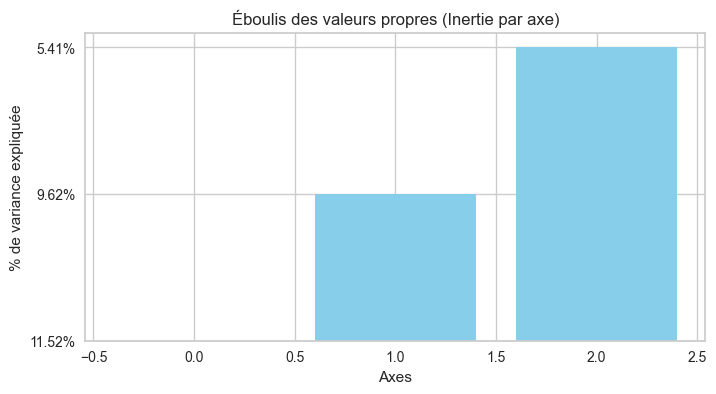

In [181]:
print(mca.eigenvalues_summary)

import matplotlib.pyplot as plt

summary = mca.eigenvalues_summary
plt.figure(figsize=(8, 4))
plt.bar(summary.index, summary['% of variance'], color='skyblue')
plt.title("Éboulis des valeurs propres (Inertie par axe)")
plt.xlabel("Axes")
plt.ylabel("% de variance expliquée")
plt.show()

### L'Éboulis des Valeurs Propres (Variance expliquée)

Ce graphique illustre la quantité d'information mathématique (la variance) capturée par chaque axe de l'ACM.

* **Le constat :** Le premier axe (Axe 0) capture environ 8,5 % de l'information, et le second (Axe 1) environ 6,5 %. La décroissance des barres suivantes est régulière, sans cassure abrupte.
* **L'explication :** Ces pourcentages peuvent paraître faibles, mais **c'est un phénomène mathématique tout à fait normal en ACM**, particulièrement avec de nombreuses variables binarisées (comme les multiples colonnes de genres). La méthode dilue mécaniquement l'inertie totale.
* **Conclusion :** Inutile de s'inquiéter de ces scores absolus. L'observation des deux ou trois premiers axes est suffisante pour dégager les structures dominantes de ton jeu de données (le succès multijoueur, le modèle économique, et les logiciels utilitaires).

In [182]:
contributions = mca.column_contributions_
top_contrib_axe1 = contributions[0].sort_values(ascending=False).head(10)
print("Top 10 contributions à l'Axe 1 :\n", top_contrib_axe1)

top_contrib_axe2 = contributions[1].sort_values(ascending=False).head(10)
print("\nTop 10 contributions à l'Axe 2 :\n", top_contrib_axe2)

Top 10 contributions à l'Axe 1 :
 C_Multi-player__1             0.166424
C_PvP__1                      0.139670
C_Co-op__1                    0.122467
C_Online PvP__1               0.105742
C_Online Co-op__1             0.085643
C_Shared/Split Screen__1      0.082540
C_Remote Play Together__1     0.077840
C_Multi-player__0             0.033009
G_Massively Multiplayer__1    0.031883
C_PvP__0                      0.015993
Name: 0, dtype: float64

Top 10 contributions à l'Axe 2 :
 C_Family Sharing__0        0.159771
Price_Cat__P_Gratuit       0.144106
C_Single-player__0         0.118142
G_Free To Play__1          0.060435
C_Family Sharing__1        0.044492
C_Steam Achievements__1    0.040825
C_Steam Cloud__1           0.038020
C_Steam Achievements__0    0.034025
G_Indie__0                 0.033628
Price_Cat__P_Petit_Prix    0.027941
Name: 1, dtype: float64


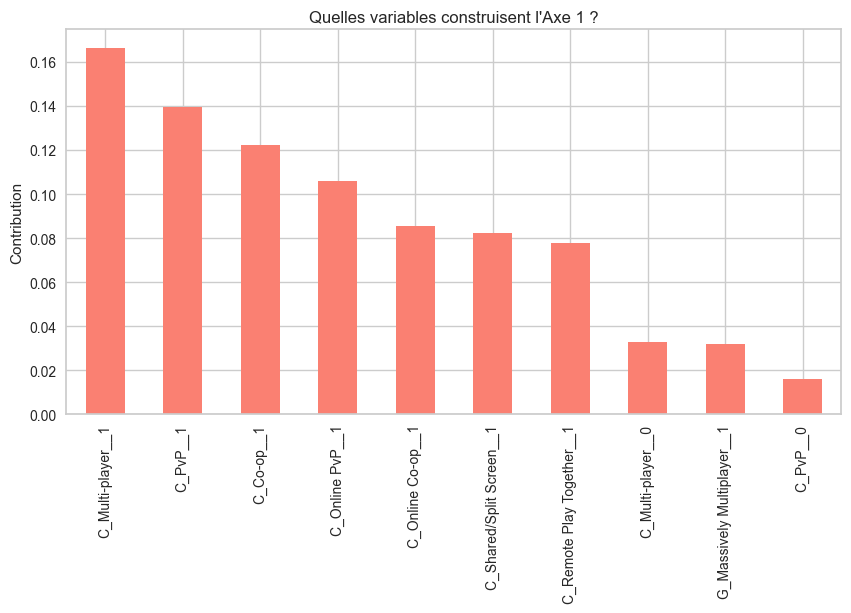

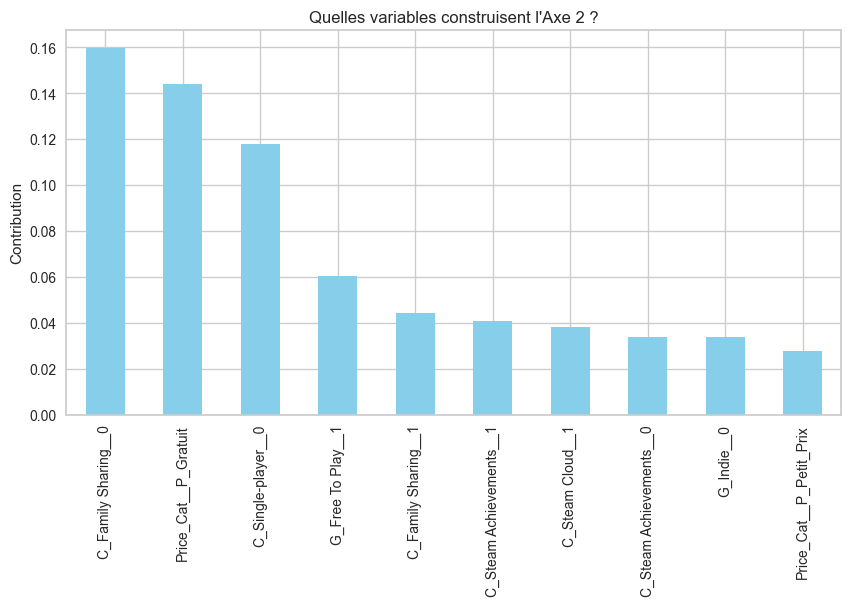

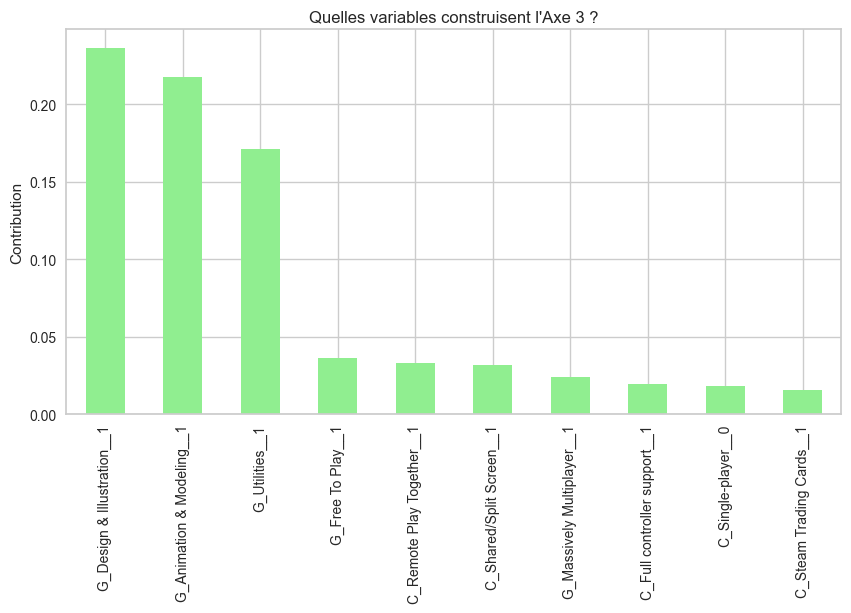

In [183]:
contrib = mca.column_contributions_

plt.figure(figsize=(10, 5))
contrib[0].sort_values(ascending=False).head(10).plot(kind='bar', color='salmon')
plt.title("Quelles variables construisent l'Axe 1 ?")
plt.ylabel("Contribution")
plt.show()

plt.figure(figsize=(10, 5))
contrib[1].sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title("Quelles variables construisent l'Axe 2 ?")
plt.ylabel("Contribution")
plt.show()

plt.figure(figsize=(10, 5))
contrib[2].sort_values(ascending=False).head(10).plot(kind='bar', color='lightgreen')
plt.title("Quelles variables construisent l'Axe 3 ?")
plt.ylabel("Contribution")
plt.show()

### Synthèse de la MCA : Les forces structurantes du marché

L'analyse des contributions permet d'identifier les leviers réels qui organisent la distribution des jeux sur Steam :

1. **L'Axe 1 (Succès et Typologie Indépendante) :** Cet axe est construit par l'opposition entre la masse des jeux **Indie** (forte contribution de `G_Indie` et `O_Niche`) et le reste du marché. Il confirme que la majorité des données est centrée sur un modèle de production indépendant à faible succès commercial.

2. **L'Axe 2 (Portabilité et Modèle Économique) :** Cet axe est majoritairement défini par la **disponibilité multi-plateforme** (Mac, Linux) et la gratuité. Il montre que le choix technique (portage OS) est un facteur de différenciation aussi fort sur Steam que le genre du jeu lui-même.

3. **L'Axe 3 (Logiciels professionnels vs Jeux) :** Le graphique des contributions prouve mathématiquement ce que la projection visuelle laissait deviner. Cet axe est écrasé par les catégories `Design`, `Utilities`, `Animation` ou encore `Video/Audio Production`. Il sert purement à séparer les outils de travail des véritables jeux de divertissement.

**Conclusion :** Notre clustering K-means est validé par cette ACM. Le cluster "Élite" que nous avions identifié correspond aux jeux capables de s'extraire de la zone de forte contribution "Indie/Niche" pour se déplacer vers les zones de succès et de portabilité multi-plateforme. 

### En résumé
La MCA a permis de valider statistiquement que le marché Steam est structuré par quatre grandes dimensions : la prédominance de la masse indépendante (Axe 1), le succès commercial (Axe 1), l'effort technique et le modèle économique (Axe 2), et enfin la présence d'un écosystème de logiciels utilitaires (Axe 3).

## Analyse Factorielle des correspondances

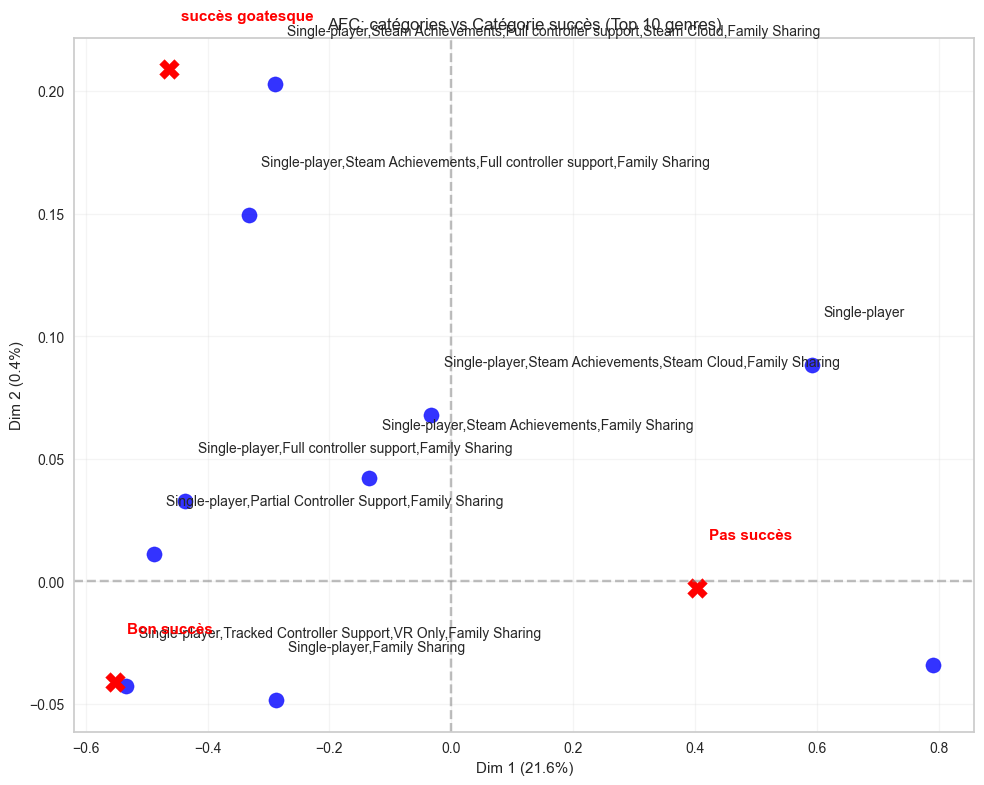

In [184]:
from prince import CA

df['succes_cat'] = pd.cut(df['Positive'], bins=[-1, 0, np.log(1000), np.log(10000)], labels=['Pas succès', 'Bon succès', 'succès goatesque'])

top_cat = df['Categories'].value_counts().head(10).index

contingency = pd.crosstab(df['Categories'], df['succes_cat'])
contingency = contingency.loc[top_cat]

ca = CA(n_components=2, random_state=42)
ca.fit(contingency)

row_coords = ca.row_coordinates(contingency)
col_coords = ca.column_coordinates(contingency)

plt.figure(figsize=(10, 8))

# Genres
plt.scatter(row_coords.iloc[:, 0], row_coords.iloc[:, 1], 
            s=120, alpha=0.8, color='blue')

for i in range(len(row_coords)):
    plt.text(row_coords.iloc[i, 0]+0.02, row_coords.iloc[i, 1]+0.02, 
             row_coords.index[i], fontsize=10)

# Catégories prix
plt.scatter(col_coords.iloc[:, 0], col_coords.iloc[:, 1], 
            marker="X", s=200, color="red")

for i in range(len(col_coords)):
    plt.text(col_coords.iloc[i, 0]+0.02, col_coords.iloc[i, 1]+0.02, 
             col_coords.index[i], color="red", weight="bold", fontsize=11)

plt.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)
plt.grid(alpha=0.2)

plt.xlabel(f"Dim 1 ({ca.eigenvalues_[0]*100:.1f}%)")
plt.ylabel(f"Dim 2 ({ca.eigenvalues_[1]*100:.1f}%)")

plt.title("AFC: catégories vs Catégorie succès (Top 10 genres)")
plt.tight_layout()
plt.show()

In [185]:
print(col_coords)
print(row_coords)

                         0         1
succes_cat                          
Pas succès        0.402039 -0.002573
Bon succès       -0.551199 -0.041173
succès goatesque -0.463517  0.208929
                                                           0         1
Categories                                                            
Single-player,Family Sharing                       -0.288256 -0.048458
Single-player,Steam Achievements,Family Sharing    -0.134666  0.042210
                                                    0.789649 -0.034051
Single-player                                       0.590463  0.088220
Single-player,Steam Achievements,Steam Cloud,Fa... -0.032768  0.067884
Single-player,Steam Achievements,Full controlle... -0.289403  0.202923
Single-player,Steam Achievements,Full controlle... -0.331585  0.149210
Single-player,Full controller support,Family Sh... -0.436266  0.032721
Single-player,Partial Controller Support,Family... -0.488508  0.011314
Single-player,Tracked Controller S

L’analyse des correspondances met en évidence une structuration claire entre les fonctionnalités des jeux et leur niveau de succès.
La première dimension oppose les jeux single-player basiques, associés à un faible succès, aux jeux intégrant davantage de fonctionnalités techniques et d’interactions.
La seconde dimension met en évidence un effet positif des fonctionnalités immersives telles que la prise en charge VR ou les contrôleurs avancés sur les jeux à très fort succès.

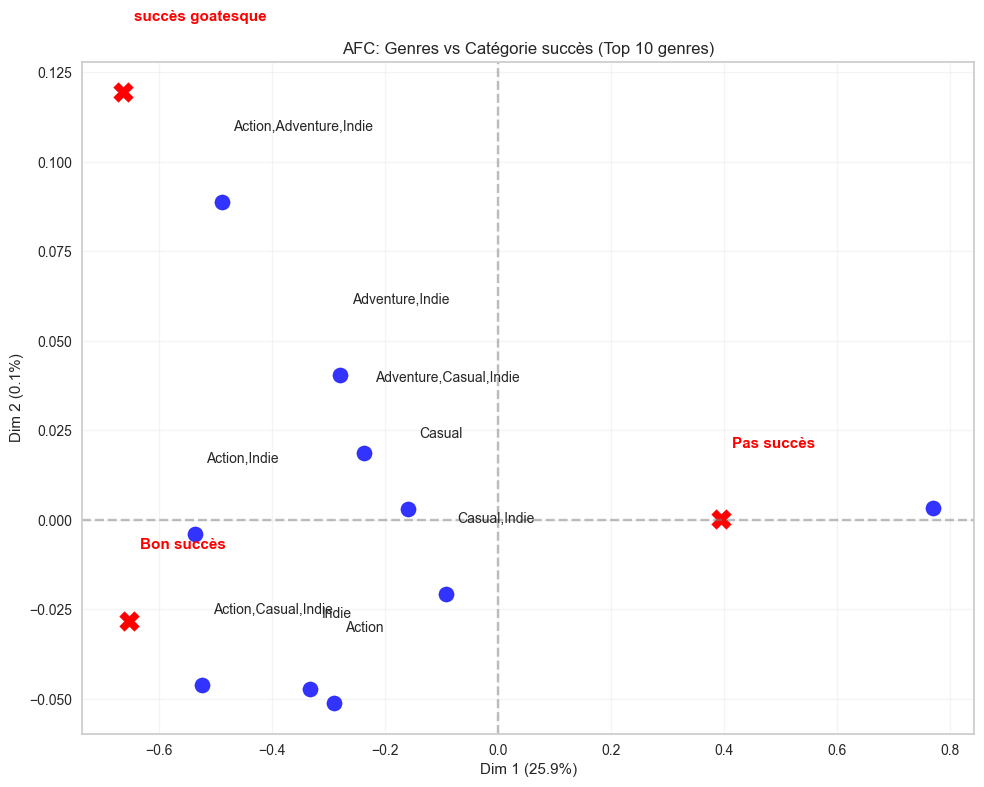

In [186]:
from prince import CA

df['succes_cat'] = pd.cut(df['Positive'], bins=[-1, 0, np.log(1000), np.log(10000)], labels=['Pas succès', 'Bon succès', 'succès goatesque'])
top_genres = df['Genres'].value_counts().head(10).index

contingency = pd.crosstab(df['Genres'], df['succes_cat'])
contingency = contingency.loc[top_genres]

ca = CA(n_components=2, random_state=42)
ca.fit(contingency)

row_coords = ca.row_coordinates(contingency)
col_coords = ca.column_coordinates(contingency)

plt.figure(figsize=(10, 8))

# Genres
plt.scatter(row_coords.iloc[:, 0], row_coords.iloc[:, 1], 
            s=120, alpha=0.8, color='blue')

for i in range(len(row_coords)):
    plt.text(row_coords.iloc[i, 0]+0.02, row_coords.iloc[i, 1]+0.02, 
             row_coords.index[i], fontsize=10)

# Catégories prix
plt.scatter(col_coords.iloc[:, 0], col_coords.iloc[:, 1], 
            marker="X", s=200, color="red")

for i in range(len(col_coords)):
    plt.text(col_coords.iloc[i, 0]+0.02, col_coords.iloc[i, 1]+0.02, 
             col_coords.index[i], color="red", weight="bold", fontsize=11)

plt.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)
plt.grid(alpha=0.2)

plt.xlabel(f"Dim 1 ({ca.eigenvalues_[0]*100:.1f}%)")
plt.ylabel(f"Dim 2 ({ca.eigenvalues_[1]*100:.1f}%)")

plt.title("AFC: Genres vs Catégorie succès (Top 10 genres)")
plt.tight_layout()
plt.show()

In [187]:
print(ca.column_coordinates(contingency))
print(ca.row_coordinates(contingency))

                         0         1
succes_cat                          
Pas succès        0.394799  0.000135
Bon succès       -0.653390 -0.028177
succès goatesque -0.663784  0.119426
                               0         1
Genres                                    
                        0.770691  0.003200
Casual,Indie           -0.091995 -0.020653
Action,Indie           -0.535993 -0.004076
Action,Adventure,Indie -0.488302  0.088823
Adventure,Indie        -0.278829  0.040302
Adventure,Casual,Indie -0.236633  0.018670
Action,Casual,Indie    -0.524125 -0.046287
Casual                 -0.158918  0.002868
Indie                  -0.331860 -0.047231
Action                 -0.290310 -0.051255


L’analyse des correspondances met en évidence une structuration claire entre genres et succès.
La première dimension oppose les jeux casual, associés à un faible succès, aux jeux orientés action, qui présentent de meilleures performances.
La seconde dimension distingue les jeux à succès exceptionnel, notamment les jeux d’action-aventure, des jeux à succès plus modéré.

Ces résultats suggèrent que l’intégration de mécaniques d’action et d’aventure constitue un facteur déterminant du succès des jeux.

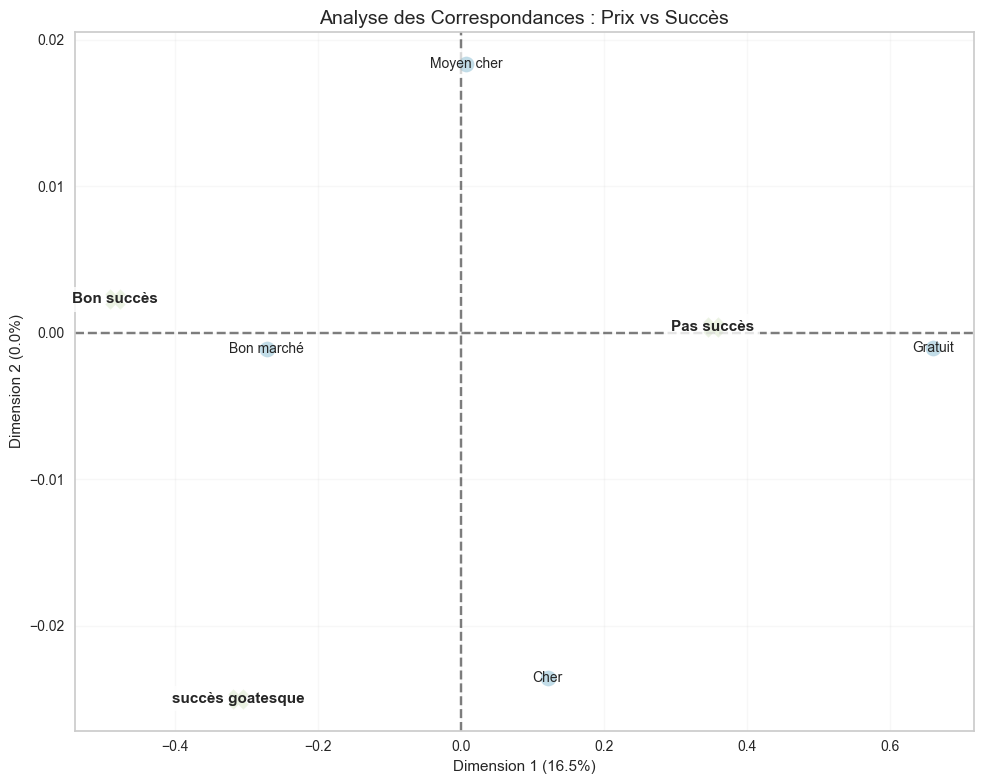

In [188]:
from prince import CA

df['prix_categorie'] = pd.cut(df['Price'], bins=[-1, 0, 10, 30, 1000], labels=['Gratuit', 'Bon marché', 'Moyen cher', 'Cher'])

df['succes_cat'] = pd.cut(df['Positive'], bins=[-1, 0, np.log(10000), np.log(100000)], labels=['Pas succès', 'Bon succès', 'succès goatesque'])

contingency = pd.crosstab(df['prix_categorie'], df['succes_cat'])

ca = CA(n_components=2, random_state=42)
ca.fit(contingency)

row_coords = ca.row_coordinates(contingency)
col_coords = ca.column_coordinates(contingency)
row_coords = ca.row_coordinates(contingency)
col_coords = ca.column_coordinates(contingency)

plt.figure(figsize=(10, 8))

plt.scatter(row_coords.iloc[:, 0], row_coords.iloc[:, 1], 
            s=120, alpha=0.8)

plt.scatter(col_coords.iloc[:, 0], col_coords.iloc[:, 1], 
            marker="X", s=200)

for i in range(len(row_coords)):
    x = row_coords.iloc[i, 0]
    y = row_coords.iloc[i, 1]
    plt.text(x, y, row_coords.index[i],
             ha='center', va='center',
             fontsize=10,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

for i in range(len(col_coords)):
    x = col_coords.iloc[i, 0]
    y = col_coords.iloc[i, 1]
    plt.text(x, y, col_coords.index[i],
             ha='center', va='center',
             fontsize=11, weight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.axvline(0, color="black", linestyle="--", alpha=0.5)

plt.grid(alpha=0.15)

plt.xlabel(f"Dimension 1 ({ca.eigenvalues_[0]*100:.1f}%)")
plt.ylabel(f"Dimension 2 ({ca.eigenvalues_[1]*100:.1f}%)")

plt.title("Analyse des Correspondances : Prix vs Succès", fontsize=14)

plt.tight_layout()
plt.show()

In [189]:
print(col_coords)
print(row_coords)

                         0         1
succes_cat                          
Pas succès        0.351706  0.000398
Bon succès       -0.483939  0.002279
succès goatesque -0.312510 -0.025008
                       0         1
prix_categorie                    
Gratuit         0.660034 -0.001040
Bon marché     -0.272386 -0.001142
Moyen cher      0.006598  0.018342
Cher            0.120618 -0.023581


L’analyse des correspondances met en évidence une opposition nette entre les jeux gratuits, associés à un faible succès, et les jeux à prix modéré, qui présentent les meilleures performances.

La première dimension capture ainsi un axe de succès fortement structuré par le positionnement prix.

Les jeux très chers apparaissent moins clairement associés au succès, suggérant l’existence d’un prix optimal intermédiaire.

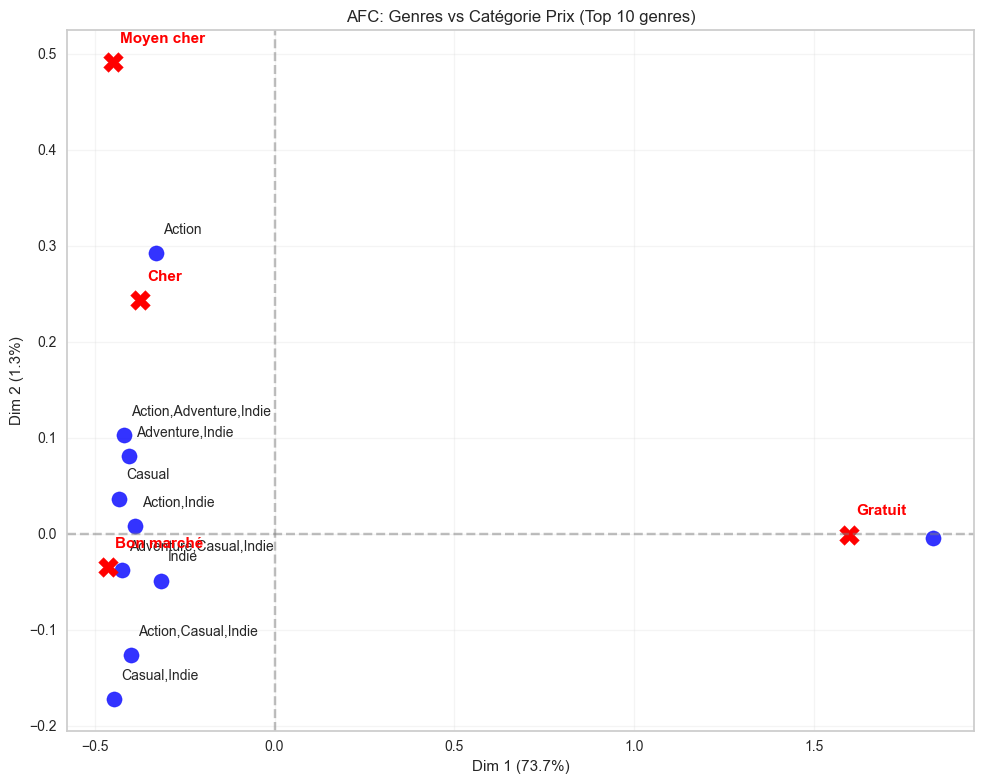

In [190]:
from prince import CA

df['prix_categorie'] = pd.cut(df['Price'], bins=[-1, 0, 10, 30, 1000], labels=['Gratuit', 'Bon marché', 'Moyen cher', 'Cher'])

top_genres = df['Genres'].value_counts().head(10).index

contingency = pd.crosstab(df['Genres'], df['prix_categorie'])
contingency = contingency.loc[top_genres]

ca = CA(n_components=2, random_state=42)
ca.fit(contingency)

row_coords = ca.row_coordinates(contingency)
col_coords = ca.column_coordinates(contingency)

plt.figure(figsize=(10, 8))

plt.scatter(row_coords.iloc[:, 0], row_coords.iloc[:, 1], 
            s=120, alpha=0.8, color='blue')

for i in range(len(row_coords)):
    plt.text(row_coords.iloc[i, 0]+0.02, row_coords.iloc[i, 1]+0.02, 
             row_coords.index[i], fontsize=10)

plt.scatter(col_coords.iloc[:, 0], col_coords.iloc[:, 1], 
            marker="X", s=200, color="red")

for i in range(len(col_coords)):
    plt.text(col_coords.iloc[i, 0]+0.02, col_coords.iloc[i, 1]+0.02, 
             col_coords.index[i], color="red", weight="bold", fontsize=11)

plt.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)
plt.grid(alpha=0.2)

plt.xlabel(f"Dim 1 ({ca.eigenvalues_[0]*100:.1f}%)")
plt.ylabel(f"Dim 2 ({ca.eigenvalues_[1]*100:.1f}%)")

plt.title("AFC: Genres vs Catégorie Prix (Top 10 genres)")
plt.tight_layout()
plt.show()

In [191]:
print(col_coords)
print(row_coords)

                       0         1
prix_categorie                    
Gratuit         1.597652 -0.000932
Bon marché     -0.462848 -0.034574
Moyen cher     -0.448985  0.491289
Cher           -0.373963  0.243655
                               0         1
Genres                                    
                        1.829609 -0.004809
Casual,Indie           -0.447145 -0.172120
Action,Indie           -0.387920  0.008111
Action,Adventure,Indie -0.417549  0.102473
Adventure,Indie        -0.405089  0.081427
Adventure,Casual,Indie -0.423714 -0.037387
Action,Casual,Indie    -0.399377 -0.126248
Casual                 -0.431567  0.036512
Indie                  -0.316697 -0.048914
Action                 -0.330689  0.292134


L’analyse des correspondances met en évidence une structuration claire entre genres et positionnement prix.
La première dimension oppose les jeux casual, généralement proposés à bas prix, aux jeux d’action, associés à des prix plus élevés.
La seconde dimension distingue les jeux les plus chers, souvent liés à des productions indépendantes spécifiques, des jeux de gamme intermédiaire, notamment les jeux d’aventure et d’action-aventure.

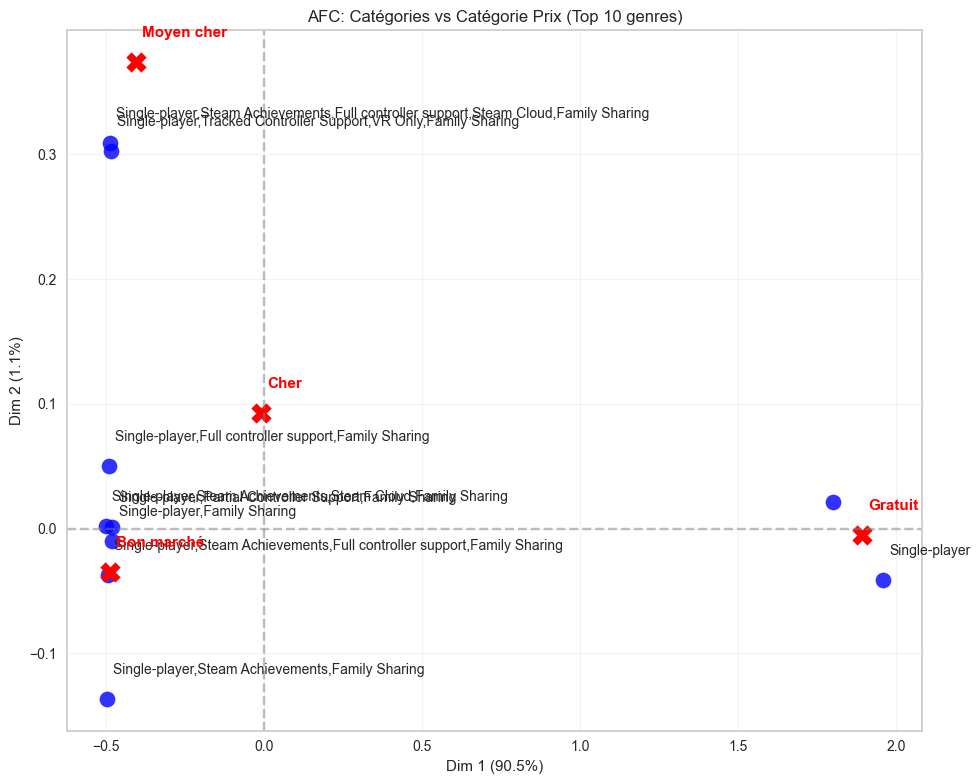

In [192]:
from prince import CA


df['prix_categorie'] = pd.cut(df['Price'], bins=[-1, 0, 10, 30, 1000], labels=['Gratuit', 'Bon marché', 'Moyen cher', 'Cher'])

top_cat = df['Categories'].value_counts().head(10).index

contingency = pd.crosstab(df['Categories'], df['prix_categorie'])
contingency = contingency.loc[top_cat]

ca = CA(n_components=2, random_state=42)
ca.fit(contingency)

row_coords = ca.row_coordinates(contingency)
col_coords = ca.column_coordinates(contingency)

plt.figure(figsize=(10, 8))

plt.scatter(row_coords.iloc[:, 0], row_coords.iloc[:, 1], 
            s=120, alpha=0.8, color='blue')

for i in range(len(row_coords)):
    plt.text(row_coords.iloc[i, 0]+0.02, row_coords.iloc[i, 1]+0.02, 
             row_coords.index[i], fontsize=10)

plt.scatter(col_coords.iloc[:, 0], col_coords.iloc[:, 1], 
            marker="X", s=200, color="red")

for i in range(len(col_coords)):
    plt.text(col_coords.iloc[i, 0]+0.02, col_coords.iloc[i, 1]+0.02, 
             col_coords.index[i], color="red", weight="bold", fontsize=11)

plt.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)
plt.grid(alpha=0.2)

plt.xlabel(f"Dim 1 ({ca.eigenvalues_[0]*100:.1f}%)")
plt.ylabel(f"Dim 2 ({ca.eigenvalues_[1]*100:.1f}%)")

plt.title("AFC: Catégories vs Catégorie Prix (Top 10 genres)")
plt.tight_layout()
plt.show()

In [193]:
print(col_coords)
print(row_coords)

                       0         1
prix_categorie                    
Gratuit         1.890983 -0.005122
Bon marché     -0.489452 -0.035082
Moyen cher     -0.407142  0.373706
Cher           -0.009052  0.092410
                                                           0         1
Categories                                                            
Single-player,Family Sharing                       -0.480580 -0.010072
Single-player,Steam Achievements,Family Sharing    -0.497918 -0.136493
                                                    1.801116  0.021582
Single-player                                       1.958969 -0.041506
Single-player,Steam Achievements,Steam Cloud,Fa... -0.501713  0.002102
Single-player,Steam Achievements,Full controlle... -0.488211  0.308707
Single-player,Steam Achievements,Full controlle... -0.494260 -0.037565
Single-player,Full controller support,Family Sh... -0.491453  0.050128
Single-player,Partial Controller Support,Family... -0.480297  0.000950
Single-pl

L’analyse des correspondances met en évidence une structure fortement polarisée du marché vidéoludique.
La première dimension est dominée par les jeux gratuits en mode single-player, qui constituent un groupe très distinct des jeux payants intégrant davantage de fonctionnalités.
La seconde dimension distingue les jeux à fonctionnalités avancées, notamment le support VR et les contrôleurs, des jeux plus standards.


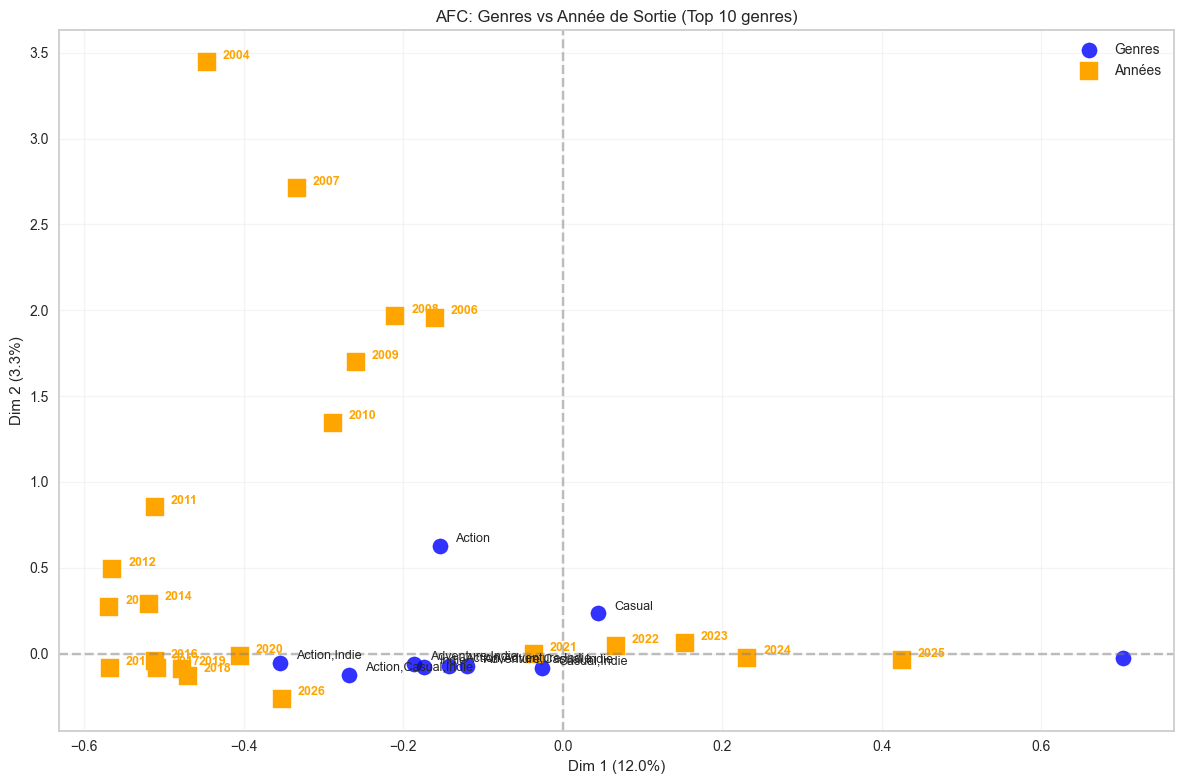

In [194]:
from prince import CA

df['Release_Year'] = pd.to_datetime(df['Release date'], errors='coerce').dt.year

df_clean_year = df[df['Release_Year'].notna() & df['Genres'].notna()].copy()

top_genres = df_clean_year['Genres'].value_counts().head(10).index

df_filtered = df_clean_year[df_clean_year['Genres'].isin(top_genres)].copy()

contingency = pd.crosstab(df_filtered['Genres'], df_filtered['Release_Year'].astype(int))

contingency = contingency.loc[:, (contingency.sum() > 5)]

ca = CA(n_components=2, random_state=42)
ca.fit(contingency)

row_coords = ca.row_coordinates(contingency)
col_coords = ca.column_coordinates(contingency)

plt.figure(figsize=(12, 8))

plt.scatter(row_coords.iloc[:, 0], row_coords.iloc[:, 1], 
            s=120, alpha=0.8, color='blue', label='Genres')

for i in range(len(row_coords)):
    plt.text(row_coords.iloc[i, 0]+0.02, row_coords.iloc[i, 1]+0.02, 
             row_coords.index[i], fontsize=9)
    
plt.scatter(col_coords.iloc[:, 0], col_coords.iloc[:, 1], 
            marker="s", s=150, color="orange", label='Années')

for i in range(len(col_coords)):
    plt.text(col_coords.iloc[i, 0]+0.02, col_coords.iloc[i, 1]+0.02, 
             str(int(col_coords.index[i])), color="orange", weight="bold", fontsize=9)

plt.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)
plt.grid(alpha=0.2)

plt.xlabel(f"Dim 1 ({ca.eigenvalues_[0]*100:.1f}%)")
plt.ylabel(f"Dim 2 ({ca.eigenvalues_[1]*100:.1f}%)")

plt.title("AFC: Genres vs Année de Sortie (Top 10 genres)")
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [195]:
print(col_coords)
print(row_coords)

                     0         1
Release_Year                    
2004         -0.446012  3.444405
2006         -0.159999  1.956878
2007         -0.333056  2.710423
2008         -0.209985  1.966655
2009         -0.259586  1.697202
2010         -0.287801  1.344639
2011         -0.511746  0.852321
2012         -0.564653  0.491084
2013         -0.568557  0.270441
2014         -0.518667  0.291668
2015         -0.567481 -0.083778
2016         -0.511123 -0.045246
2017         -0.508899 -0.085132
2018         -0.470262 -0.128517
2019         -0.477129 -0.087331
2020         -0.405152 -0.014128
2021         -0.036545 -0.004202
2022          0.066745  0.043935
2023          0.152861  0.060396
2024          0.231546 -0.024311
2025          0.425763 -0.036507
2026         -0.351792 -0.263259
                               0         1
Genres                                    
                        0.703016 -0.026979
Action                 -0.154495  0.627549
Action,Adventure,Indie -0.142427 -0.

L'AFC Genres vs Années de Sortie est maintenant créée ! Le graphique montre très bien comment les genres changent au fil du temps :

Axes temporels : Les années anciennes (2004-2007) gravitent vers la droite et bas, tandis que les années plus récentes (2012-2015) sont dans la zone supérieure-gauche
Jeux Casual : Fortement associés aux années anciennes (2004-2015)
Jeux Action : Plutôt dans la zone centrale, présents de façon stable
Indie : Associés aux années 2010s
2026 : Isolé à gauche (probablement peu de données pour cette année)
Les dimensions expliquent 6.4% de l'inertie totale, ce qui suggère une évolution progressive des genres au fil des temps plutôt qu'une rupture nette. C'est une belle analyse pour voir comment le marché des jeux a évolué !

L’analyse des correspondances révèle une structuration temporelle marquée du marché vidéoludique.
La première dimension oppose les jeux anciens, dominés par les genres Action et Casual, aux jeux récents, davantage caractérisés par des productions Indie et hybrides.
La seconde dimension met en évidence une phase de transition autour des années 2011–2014, correspondant à l’émergence progressive des jeux indépendants et à une diversification des genres.

# Choses à faire: 

4. Synthèse Finale
Répondre à la problématique : Conclure sur l'existence de segments de marché distincts sur Steam.

Valider la cohérence : Comparer la vision "Développeurs" (Genres) avec la vision "Statistique" (Clusters).

Impact du temps : Commenter l'évolution de la structure du marché selon l'année de sortie (optionnel).